<xarray.Dataset> Size: 147MB
Dimensions:         (year: 28, lat: 128, lon: 256, doy: 365)
Coordinates:
  * year            (year) int64 224B 1985 1986 1987 1988 ... 2010 2011 2012
  * lat             (lat) float64 1kB -88.93 -87.54 -86.14 ... 86.14 87.54 88.93
  * lon             (lon) float64 2kB 0.0 1.406 2.812 ... 355.8 357.2 358.6
  * doy             (doy) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables: (12/13)
    onset_jday      (year, lat, lon) float32 4MB ...
    onset_day       (year, lat, lon) float32 4MB ...
    onset_month     (year, lat, lon) float32 4MB ...
    onset_year      (year, lat, lon) float32 4MB ...
    demise_jday     (year, lat, lon) float32 4MB ...
    demise_day      (year, lat, lon) float32 4MB ...
    ...              ...
    demise_year     (year, lat, lon) float32 4MB ...
    totwet          (year, lat, lon) float32 4MB ...
    totdry          (year, lat, lon) float32 4MB ...
    durwet          (year, lat, lon) timedelta64[ns] 7MB ..

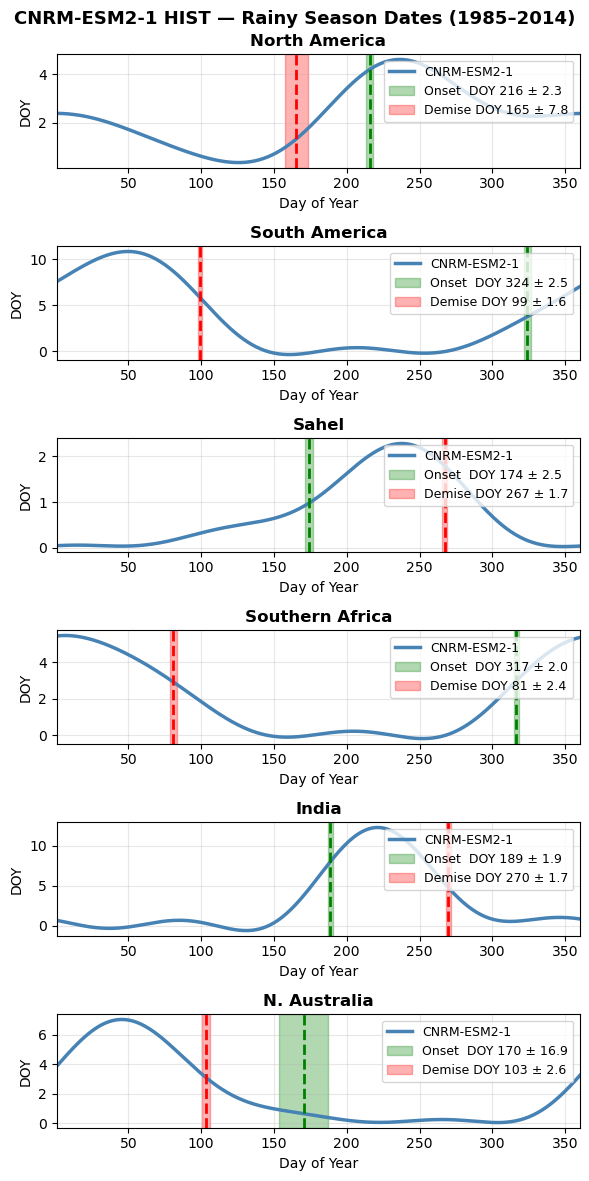

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ── Load the file ─────────────────────────────────────────────────────────────
# nc_file = Path("~/UoE/20260218_Monsoons/rainyseason_output_files/rainy_season_UKESM1-0-LL_HIST_1985-2014.nc").expanduser()
nc_file = Path("~/UoE/20260218_Monsoons/rainyseason_output_files/rainy_season_CNRM-ESM2-1_HIST_1985-2014.nc").expanduser()

ds_out  = xr.open_dataset(nc_file)
missval = -999.0

lats = ds_out.lat.values
lons = ds_out.lon.values
model_name = ds_out.attrs["model"]
exp        = ds_out.attrs["experiment"]
out_dir    = nc_file.parent

print(ds_out)

# ── Domain definitions ────────────────────────────────────────────────────────
domains = {
    "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}

# ── Reconstruct smoothed annual cycle from onset/demise jday ─────────────────
# NOTE: 'smoothed' array from Step 3 is not saved in the NetCDF.
# We reconstruct the climatological mean annual cycle directly from ds_out
# using onset_jday as a proxy check, but for the cycle we use the raw
# DOY climatology from onset/demise patterns.
# Best option: reload prec and recompute, OR just plot raw DOY climatology.
# Here we plot mean onset/demise only — add smoothed cycle if prec is available.

fig, axes = plt.subplots(6, 1, figsize=(6, 12))

for ax, (region, dom) in zip(axes.flat, domains.items()):
    lat_min, lat_max = dom["lat"]
    lon_min, lon_max = dom["lon"]

    ilat = np.where((lats >= lat_min) & (lats <= lat_max))[0]
    ilon = np.where((lons >= lon_min) & (lons <= lon_max))[0]

    # ── Smoothed annual cycle ─────────────────────────────────────────────────
    sc = ds_out["smoothed_cycle"].values[:, ilat, :][:, :, ilon].copy()
    sc = np.clip(np.nanmean(sc, axis=(1, 2)), None, None)
    doys = np.arange(1, len(sc) + 1)
    ax.plot(doys, sc, color="steelblue", linewidth=2.5, label=model_name)
    ax.set_ylabel("P [mm/day]")   # update ylabel too

    # Onset / demise
    onset_domain  = ds_out["onset_jday"].values[:, ilat, :][:, :, ilon].copy().astype(float)
    demise_domain = ds_out["demise_jday"].values[:, ilat, :][:, :, ilon].copy().astype(float)
    onset_domain[onset_domain   == missval] = np.nan
    demise_domain[demise_domain == missval] = np.nan

    onset_yearly  = np.nanmean(onset_domain,  axis=(1, 2))
    demise_yearly = np.nanmean(demise_domain, axis=(1, 2))

    n_onset  = np.sum(~np.isnan(onset_yearly))
    n_demise = np.sum(~np.isnan(demise_yearly))

    mean_onset  = np.nanmean(onset_yearly)
    mean_demise = np.nanmean(demise_yearly)
    se_onset    = np.nanstd(onset_yearly)  / np.sqrt(n_onset)  if n_onset  > 1 else 0
    se_demise   = np.nanstd(demise_yearly) / np.sqrt(n_demise) if n_demise > 1 else 0

    # Onset/demise lines only (no smoothed cycle — smoothed not saved in NC)
    ax.axvline(mean_onset,  color="green", linewidth=2, linestyle="--")
    ax.axvspan(mean_onset  - se_onset,  mean_onset  + se_onset,
               alpha=0.3, color="green",
               label=f"Onset  DOY {mean_onset:.0f} ± {se_onset:.1f}")
    ax.axvline(mean_demise, color="red",   linewidth=2, linestyle="--")
    ax.axvspan(mean_demise - se_demise, mean_demise + se_demise,
               alpha=0.3, color="red",
               label=f"Demise DOY {mean_demise:.0f} ± {se_demise:.1f}")

    ax.set_title(f"{region}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Day of Year")
    ax.set_ylabel("DOY")
    ax.set_xlim(1, 360)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.3)

plt.suptitle(f"{model_name} {exp} — Rainy Season Dates (1985–2014)", fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig(out_dir / f"annual_cycle_check_{model_name}_{exp}.png", dpi=150, bbox_inches="tight")
plt.show()

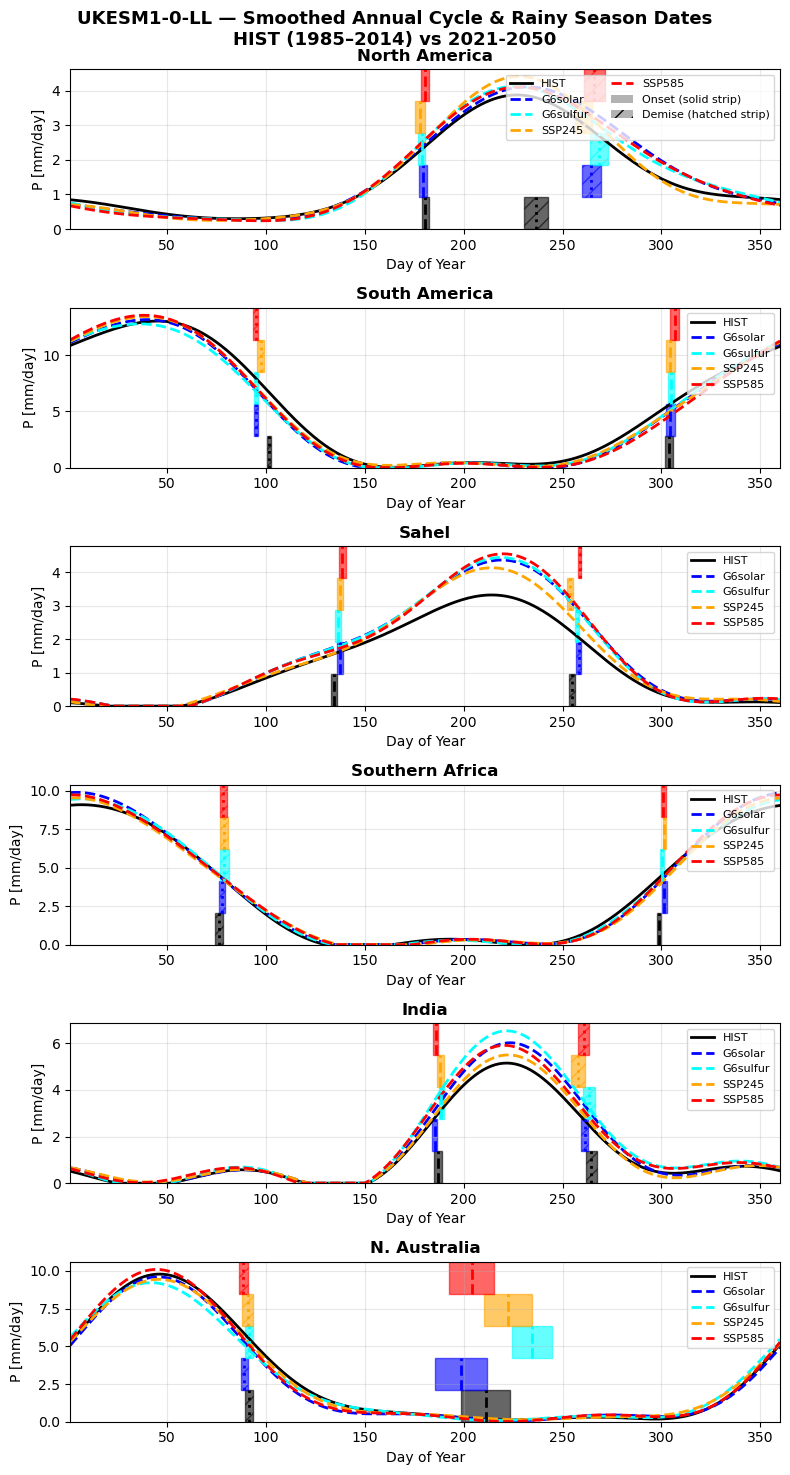

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

base_dir = Path("~/UoE/20260218_Monsoons/rainyseason_output_files").expanduser()
missval  = -999.0

# ── File groups ───────────────────────────────────────────────────────────────
groups = {
    "2021-2050": [
        ("HIST",     "rainy_season_UKESM1-0-LL_HIST_1985-2014.nc",     "black"),
        ("G6solar",  "rainy_season_UKESM1-0-LL_G6solar_2021-2050.nc",  "blue"),
        ("G6sulfur", "rainy_season_UKESM1-0-LL_G6sulfur_2021-2050.nc", "cyan"),
        ("SSP245",   "rainy_season_UKESM1-0-LL_SSP245_2021-2050.nc",   "orange"),
        ("SSP585",   "rainy_season_UKESM1-0-LL_SSP585_2021-2050.nc",   "red"),
    ],
    "2071-2100": [
        ("HIST",     "rainy_season_UKESM1-0-LL_HIST_1985-2014.nc",     "black"),
        ("G6solar",  "rainy_season_UKESM1-0-LL_G6solar_2071-2100.nc",  "blue"),
        ("G6sulfur", "rainy_season_UKESM1-0-LL_G6sulfur_2071-2100.nc", "cyan"),
        ("SSP245",   "rainy_season_UKESM1-0-LL_SSP245_2071-2100.nc",   "orange"),
        ("SSP585",   "rainy_season_UKESM1-0-LL_SSP585_2071-2100.nc",   "red"),
    ],
}

domains = {
    "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}

# ── Plot one group ────────────────────────────────────────────────────────────
group_label = "2021-2050"   # ← change to "2071-2100" for second group
file_list   = groups[group_label]

n_exp  = len(file_list)      # 5
n_dom  = len(domains)        # 6

fig, axes = plt.subplots(n_dom, 1, figsize=(8, 15))

for ax, (region, dom) in zip(axes.flat, domains.items()):
    ilat = np.where((lats_ref >= dom["lat"][0]) & (lats_ref <= dom["lat"][1]))[0] \
           if False else None   # will be set per file below

    ymin, ymax = 0, 1   # will update after first plot
    lines = []

    for i, (exp_label, fname, color) in enumerate(file_list):
        nc_file = base_dir / fname
        if not nc_file.exists():
            print(f"  SKIP {fname}")
            continue

        ds      = xr.open_dataset(nc_file)
        lats    = ds.lat.values
        lons    = ds.lon.values
        tot_int = ds.sizes["doy"]

        ilat = np.where((lats >= dom["lat"][0]) & (lats <= dom["lat"][1]))[0]
        ilon = np.where((lons >= dom["lon"][0]) & (lons <= dom["lon"][1]))[0]

        # Smoothed annual cycle
        sc   = ds["smoothed_cycle"].values[:, ilat, :][:, :, ilon].copy()
        sc   = np.clip(np.nanmean(sc, axis=(1, 2)), 0, None)
        doys = np.arange(1, tot_int + 1)

        line, = ax.plot(doys, sc, color=color, linewidth=2,
                        label=exp_label, linestyle="-" if exp_label=="HIST" else "--")
        lines.append(line)

        # Onset / demise stats
        for key, ls in [("onset_jday", "onset"), ("demise_jday", "demise")]:
            arr = ds[key].values[:, ilat, :][:, :, ilon].copy().astype(float)
            arr[arr == missval] = np.nan
            yearly = np.nanmean(arr, axis=(1, 2))
            n  = np.sum(~np.isnan(yearly))
            mu = np.nanmean(yearly)
            se = np.nanstd(yearly) / np.sqrt(n) if n > 1 else 0

            # Store for drawing strips after y-limits known
            if key == "onset_jday":
                onset_mu, onset_se = mu, se
            else:
                demise_mu, demise_se = mu, se

        ds.close()

        # Draw onset/demise as vertical strips of height = yaxis/5
        # We use a fraction of the y-axis height per experiment (stacked)
        # We'll draw after the loop once ylim is set — store values
        ax._strip_data = getattr(ax, '_strip_data', [])
        ax._strip_data.append((i, color, onset_mu, onset_se, demise_mu, demise_se))

    ax.set_title(region, fontsize=12, fontweight="bold")
    ax.set_xlabel("Day of Year")
    ax.set_ylabel("P [mm/day]")
    ax.set_xlim(1, 360)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

    # ── Draw onset/demise strips ──────────────────────────────────────────────
    ylo, yhi   = ax.get_ylim()
    strip_h    = (yhi - ylo) / n_exp          # height of each strip
    label_done = set()

    for i, color, onset_mu, onset_se, demise_mu, demise_se in ax._strip_data:
        ybot = ylo + i * strip_h
        ytop = ybot + strip_h

        # Onset strip
        lbl_on  = f"{file_list[i][0]} onset"  if file_list[i][0] not in label_done else ""
        lbl_dem = f"{file_list[i][0]} demise" if file_list[i][0] not in label_done else ""
        ax.axvspan(onset_mu  - onset_se,  onset_mu  + onset_se,
                   ymin=(ybot-ylo)/(yhi-ylo), ymax=(ytop-ylo)/(yhi-ylo),
                   alpha=0.6, color=color)
        ax.axvline(onset_mu,  ymin=(ybot-ylo)/(yhi-ylo), ymax=(ytop-ylo)/(yhi-ylo),
                   color=color, linewidth=2, linestyle="--")

        # Demise strip
        ax.axvspan(demise_mu - demise_se, demise_mu + demise_se,
                   ymin=(ybot-ylo)/(yhi-ylo), ymax=(ytop-ylo)/(yhi-ylo),
                   alpha=0.6, color=color, hatch="//")
        ax.axvline(demise_mu, ymin=(ybot-ylo)/(yhi-ylo), ymax=(ytop-ylo)/(yhi-ylo),
                   color=color, linewidth=2, linestyle=":")

        label_done.add(file_list[i][0])

    # Legend for curves
    ax.legend(handles=lines, fontsize=8, loc="upper right")

# ── Custom legend for strip meaning ──────────────────────────────────────────
from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor="grey", alpha=0.6, label="Onset (solid strip)"),
    Patch(facecolor="grey", alpha=0.6, hatch="//", label="Demise (hatched strip)"),
]
axes[0].legend(handles=lines + legend_els, fontsize=8, loc="upper right", ncol=2)

plt.suptitle(f"UKESM1-0-LL — Smoothed Annual Cycle & Rainy Season Dates\n"
             f"HIST (1985–2014) vs {group_label}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig(base_dir / f"UKESM1-0-LL_annual_cycle_comparison_{group_label}.png",
#             dpi=150, bbox_inches="tight")
plt.show()

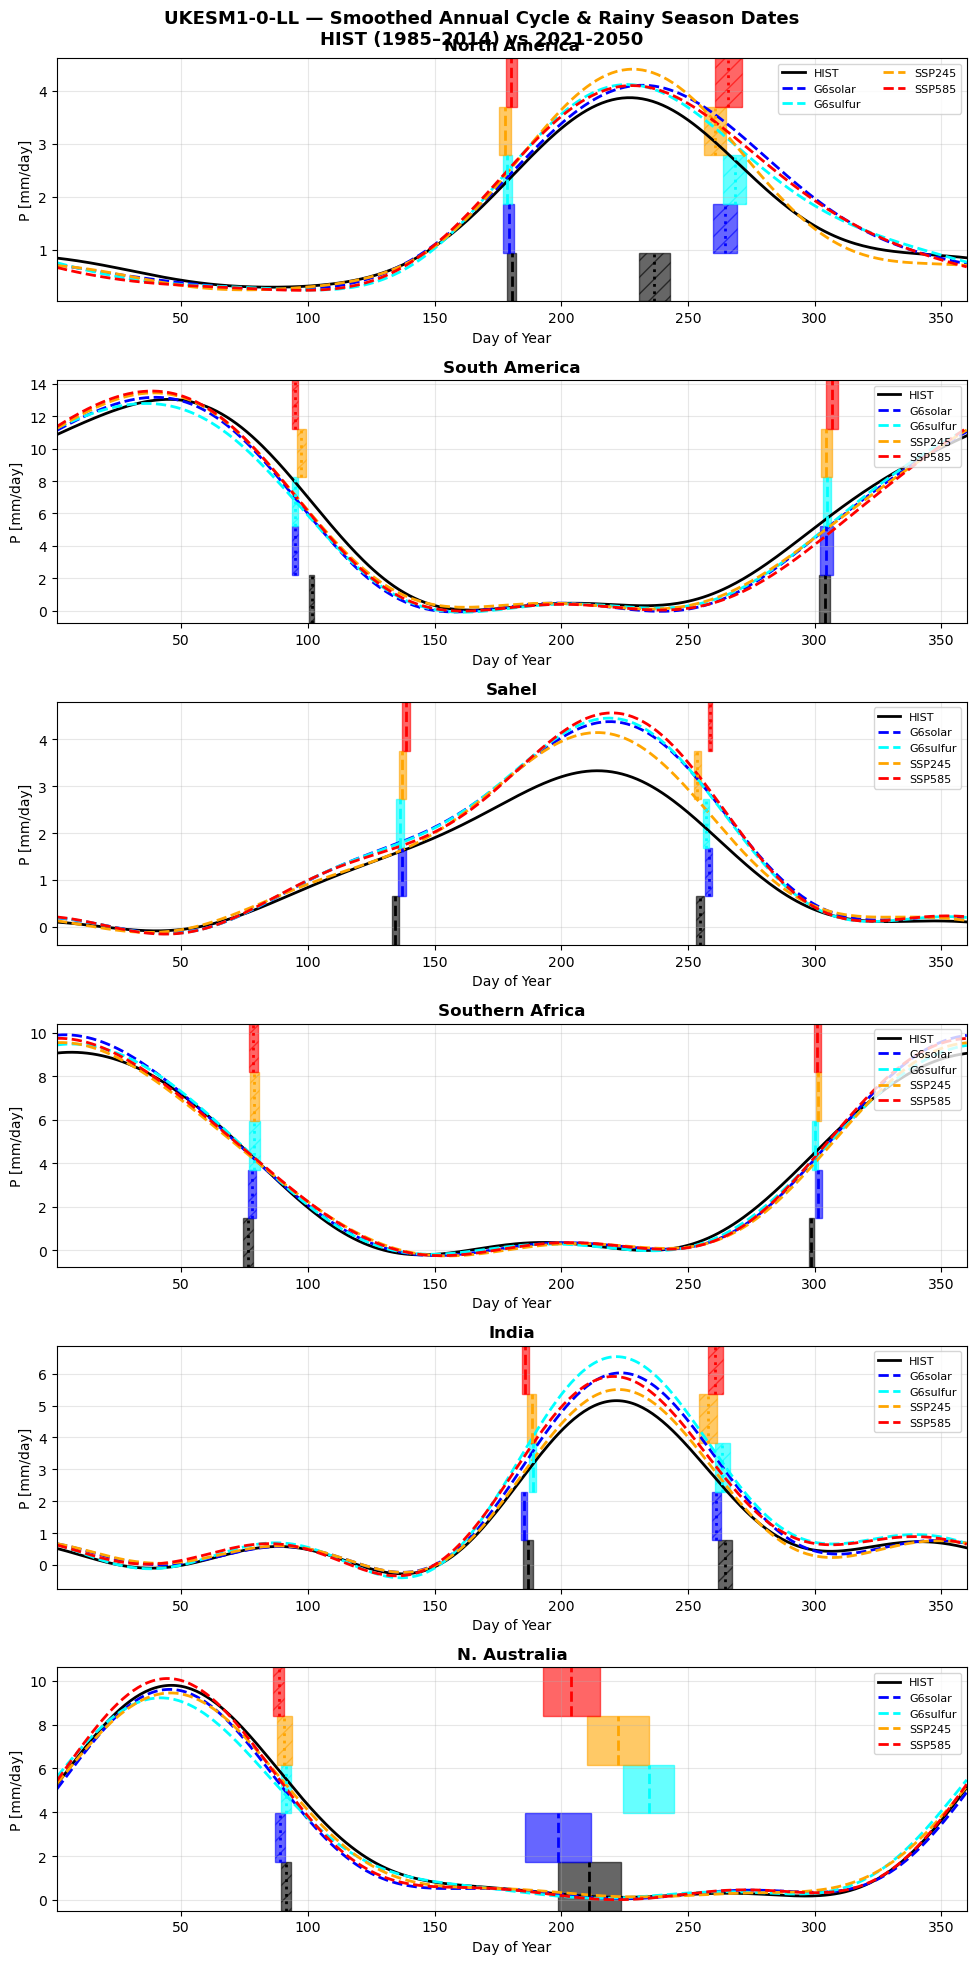

Saved → UKESM1-0-LL_annual_cycle_comparison_2021-2050.png


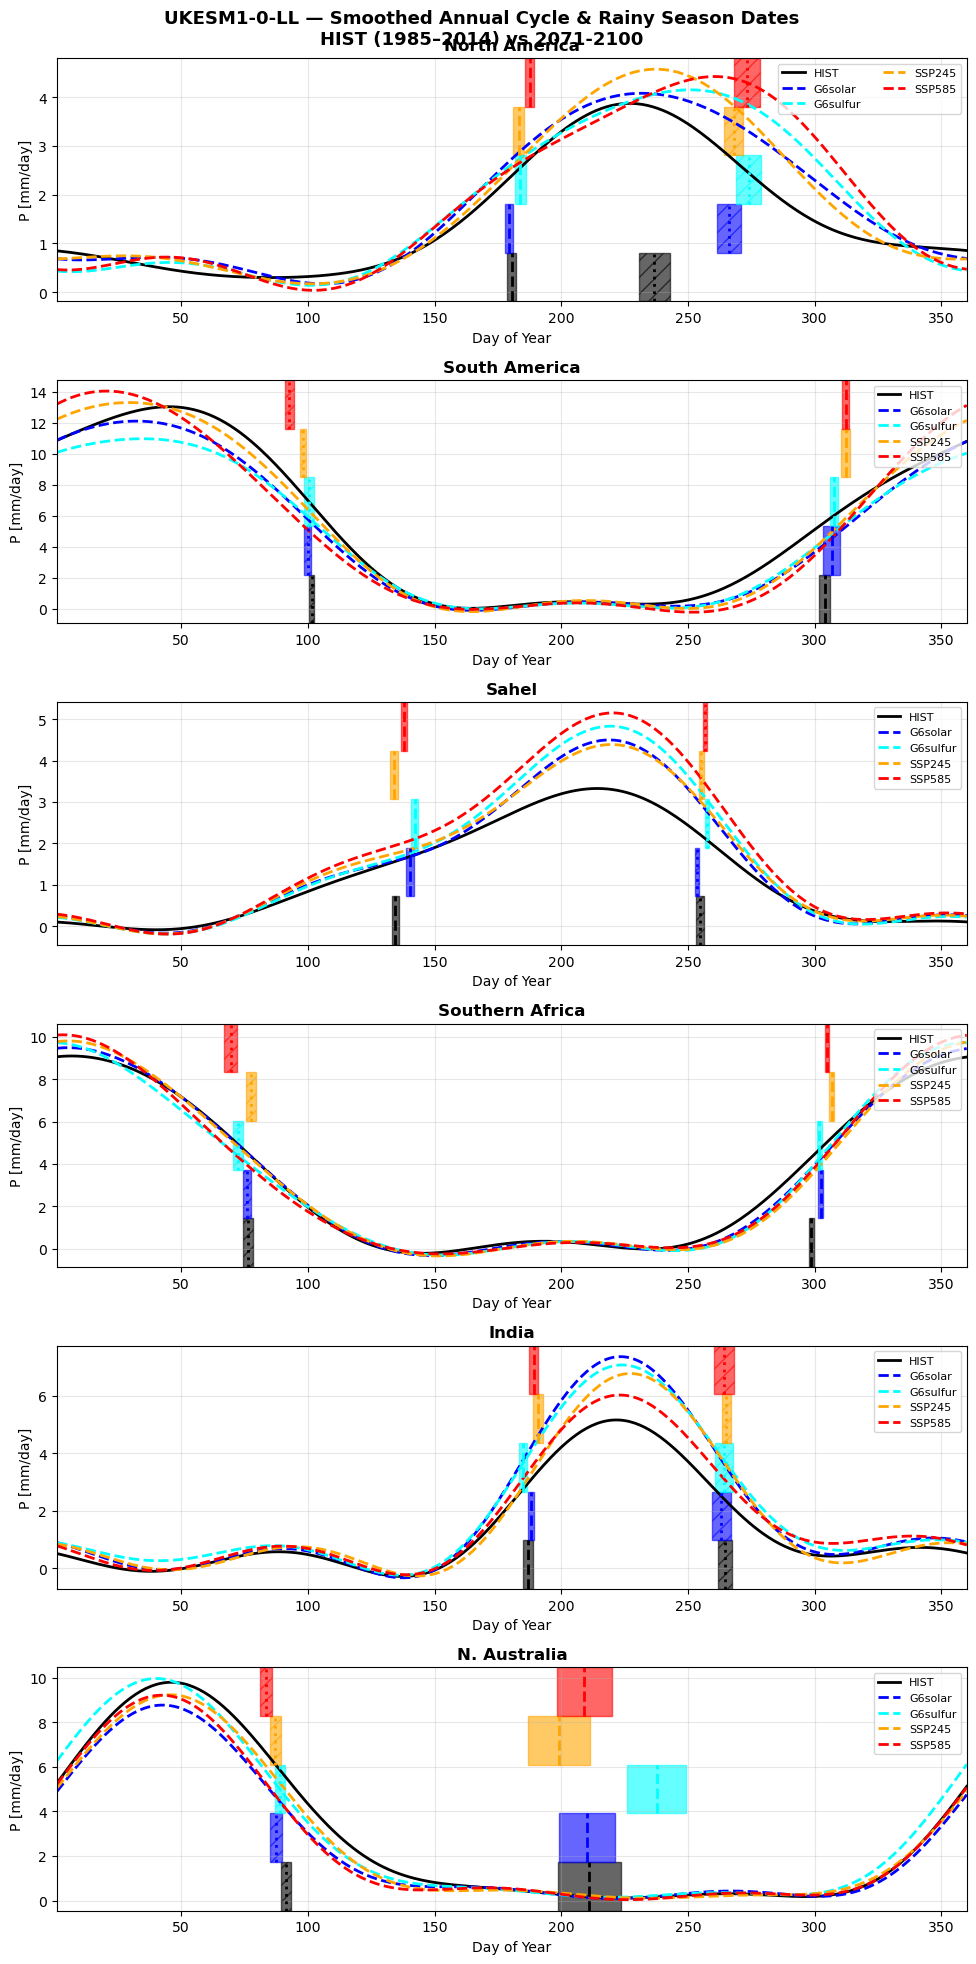

Saved → UKESM1-0-LL_annual_cycle_comparison_2071-2100.png


In [3]:
for group_label, file_list in groups.items():

    n_exp = len(file_list)
    n_dom = len(domains)

    fig, axes = plt.subplots(n_dom, 1, figsize=(10, 20))

    for ax, (region, dom) in zip(axes.flat, domains.items()):

        lines = []

        for i, (exp_label, fname, color) in enumerate(file_list):
            nc_file = base_dir / fname
            if not nc_file.exists():
                print(f"  SKIP {fname}")
                continue

            ds      = xr.open_dataset(nc_file)
            lats    = ds.lat.values
            lons    = ds.lon.values
            tot_int = ds.sizes["doy"]

            ilat = np.where((lats >= dom["lat"][0]) & (lats <= dom["lat"][1]))[0]
            ilon = np.where((lons >= dom["lon"][0]) & (lons <= dom["lon"][1]))[0]

            sc   = ds["smoothed_cycle"].values[:, ilat, :][:, :, ilon].copy()
            sc   = np.clip(np.nanmean(sc, axis=(1, 2)), None, None)
            doys = np.arange(1, tot_int + 1)

            line, = ax.plot(doys, sc, color=color, linewidth=2,
                            label=exp_label, linestyle="-" if exp_label=="HIST" else "--")
            lines.append(line)

            for key in ["onset_jday", "demise_jday"]:
                arr = ds[key].values[:, ilat, :][:, :, ilon].copy().astype(float)
                arr[arr == missval] = np.nan
                yearly = np.nanmean(arr, axis=(1, 2))
                n  = np.sum(~np.isnan(yearly))
                mu = np.nanmean(yearly)
                se = np.nanstd(yearly) / np.sqrt(n) if n > 1 else 0
                if key == "onset_jday":
                    onset_mu, onset_se = mu, se
                else:
                    demise_mu, demise_se = mu, se

            ds.close()

            ax._strip_data = getattr(ax, '_strip_data', [])
            ax._strip_data.append((i, color, onset_mu, onset_se, demise_mu, demise_se))

        ax.set_title(region, fontsize=12, fontweight="bold")
        ax.set_xlabel("Day of Year")
        ax.set_ylabel("P [mm/day]")
        ax.set_xlim(1, 360)
        # ax.set_ylim(bottom=0)
        ax.grid(True, alpha=0.3)

        ylo, yhi = ax.get_ylim()
        strip_h  = (yhi - ylo) / n_exp

        for i, color, onset_mu, onset_se, demise_mu, demise_se in ax._strip_data:
            ybot = ylo + i * strip_h
            ytop = ybot + strip_h
            yfrac_bot = (ybot - ylo) / (yhi - ylo)
            yfrac_top = (ytop - ylo) / (yhi - ylo)

            ax.axvspan(onset_mu  - onset_se,  onset_mu  + onset_se,
                       ymin=yfrac_bot, ymax=yfrac_top, alpha=0.6, color=color)
            ax.axvline(onset_mu,  ymin=yfrac_bot, ymax=yfrac_top,
                       color=color, linewidth=2, linestyle="--")
            ax.axvspan(demise_mu - demise_se, demise_mu + demise_se,
                       ymin=yfrac_bot, ymax=yfrac_top, alpha=0.6, color=color, hatch="//")
            ax.axvline(demise_mu, ymin=yfrac_bot, ymax=yfrac_top,
                       color=color, linewidth=2, linestyle=":")

        ax.legend(handles=lines, fontsize=8, loc="upper right")

    from matplotlib.patches import Patch
    legend_els = []
    #     Patch(facecolor="grey", alpha=0.6,          label="Onset (solid)"),
    #     Patch(facecolor="grey", alpha=0.6, hatch="//", label="Demise (hatched)"),
    # ]
    axes[0].legend(handles=lines + legend_els, fontsize=8, loc="upper right", ncol=2)

    plt.suptitle(f"UKESM1-0-LL — Smoothed Annual Cycle & Rainy Season Dates\n"
                 f"HIST (1985–2014) vs {group_label}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    outpng = base_dir / f"UKESM1-0-LL_annual_cycle_comparison_{group_label}.png"
    plt.savefig(outpng, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {outpng.name}")

In [4]:
#THIS IS THE OLD FUNCTION
#SINCE DURATION IS GIVING SOME ERROR, I HAD TO MODIFY
#THIS FUNCTION SO THAT IT CALCULATES THE DURATION FROM ONSET AND DEMISE

# def get_annual_values(ds, ilat, ilon, key):
#     arr = ds[key].values[:, ilat, :][:, :, ilon].copy().astype(float)
#     arr[arr == missval] = np.nan
#     arr[arr < 0.]       = np.nan   # catch any residual negatives

#     # Physical upper bounds per variable
#     bounds = {"onset_jday": 366, "demise_jday": 366,
#               "durwet": 366, "durdry": 366,
#               "totwet": 5000, "totdry": 5000}
#     if key in bounds:
#         arr[arr > bounds[key]] = np.nan

#     return np.nanmean(arr, axis=(1, 2))


def get_annual_values(ds, ilat, ilon, key):
    """Return spatial mean per year with NaNs for missing."""
    if key == "durwet":
        onset  = ds["onset_jday"].values[:, ilat, :][:, :, ilon].copy().astype(float)
        demise = ds["demise_jday"].values[:, ilat, :][:, :, ilon].copy().astype(float)
        onset[onset   == missval] = np.nan
        demise[demise == missval] = np.nan
        dur = demise - onset
        tot = ds.sizes["doy"]
        dur[dur < 0] += tot          # straddles year boundary
        dur[(dur <= 0) | (dur > tot)] = np.nan
        arr = dur
    else:
        arr = ds[key].values[:, ilat, :][:, :, ilon].copy().astype(float)
        arr[arr == missval] = np.nan
        bounds = {"onset_jday": 366, "demise_jday": 366, "totwet": 5000}
        if key in bounds:
            arr[arr > bounds[key]] = np.nan
        arr[arr < 0] = np.nan
    return np.nanmean(arr, axis=(1, 2))

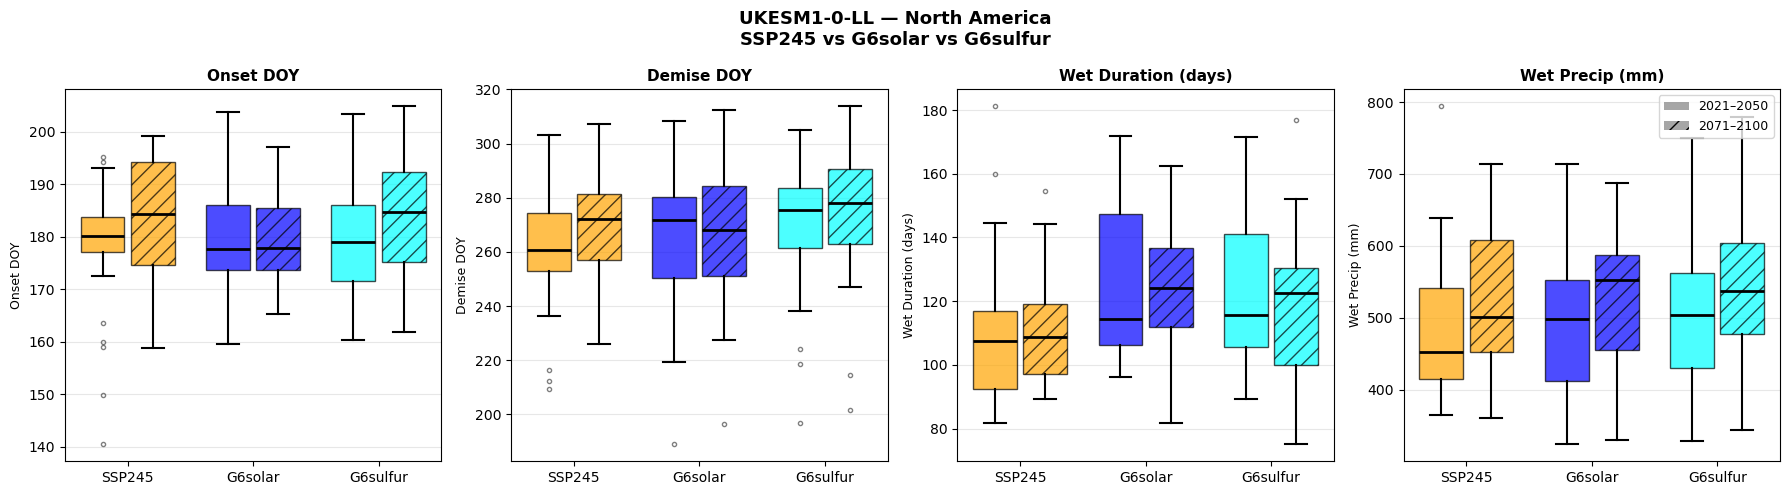

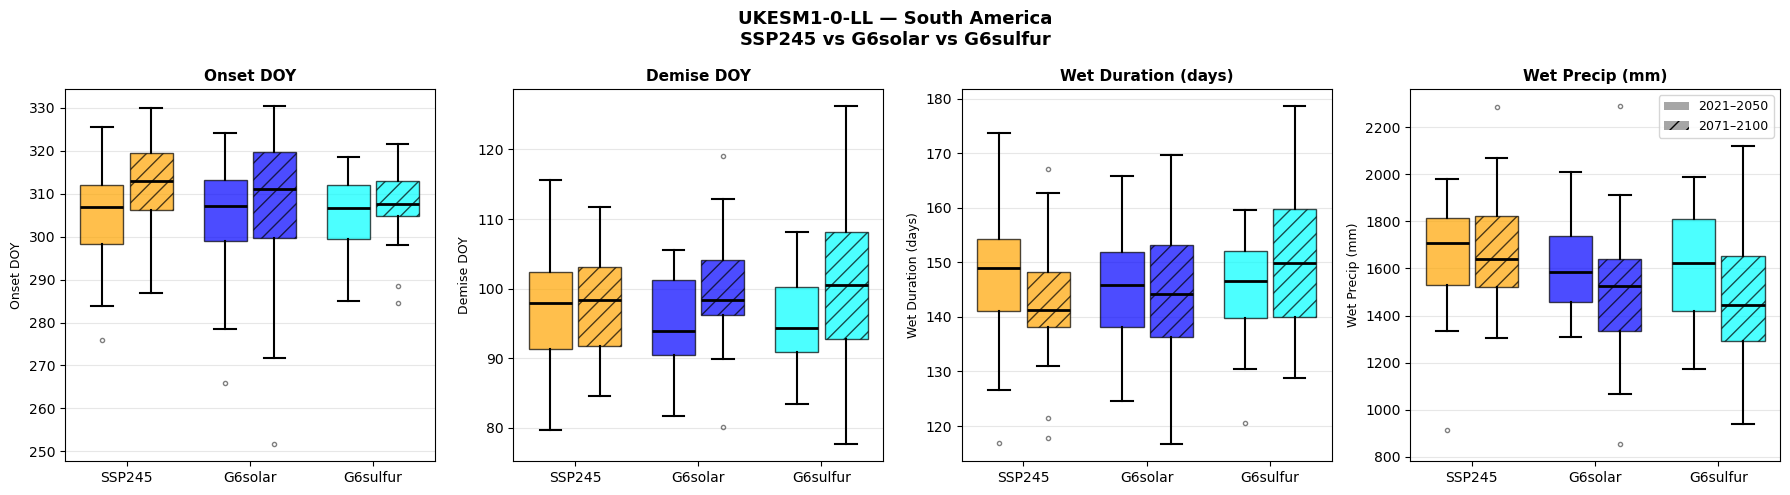

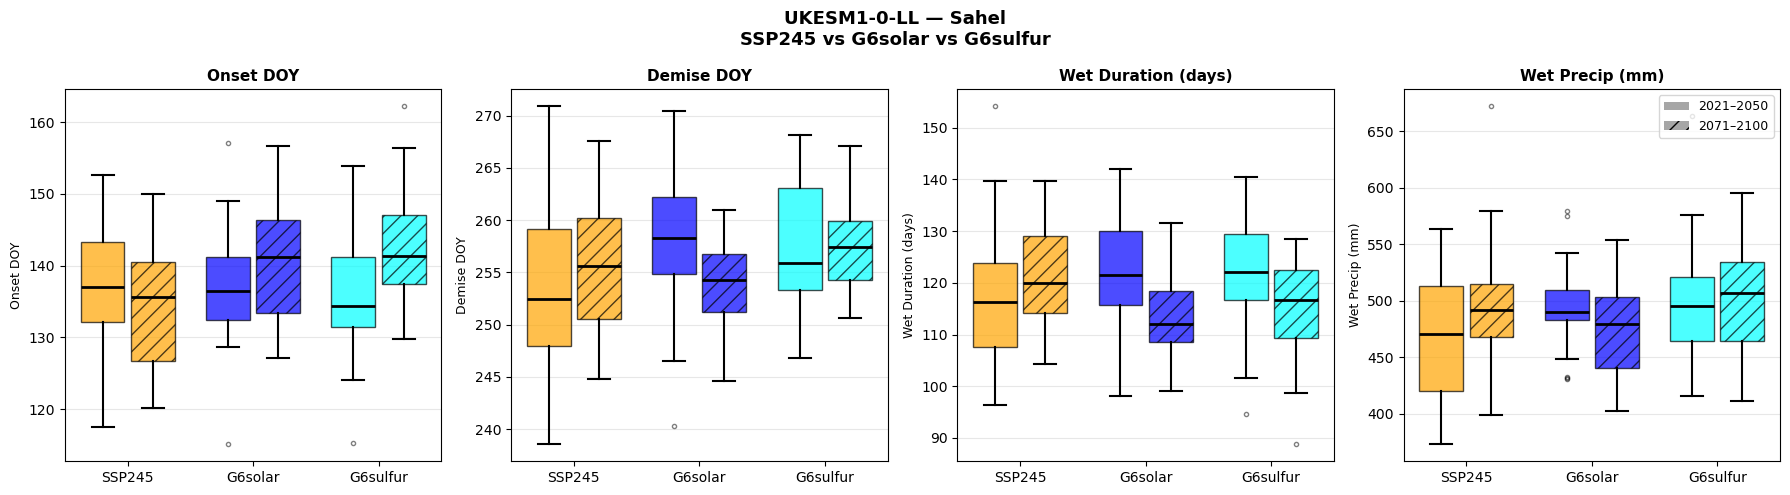

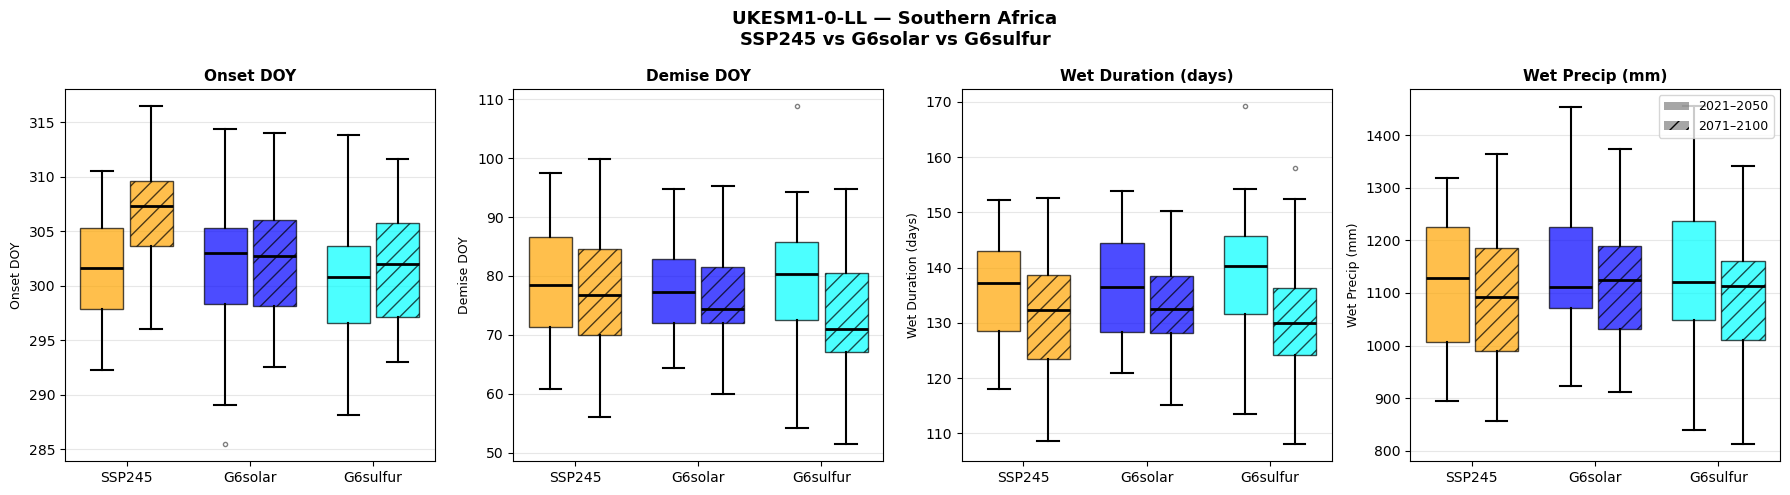

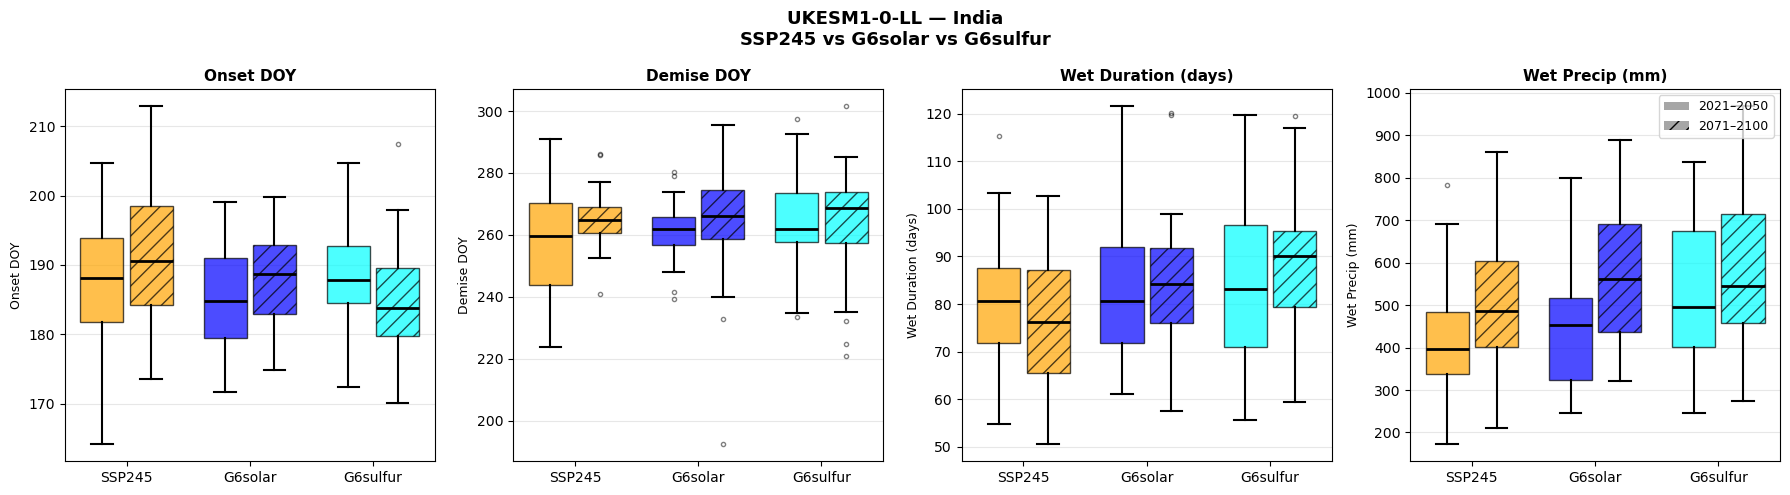

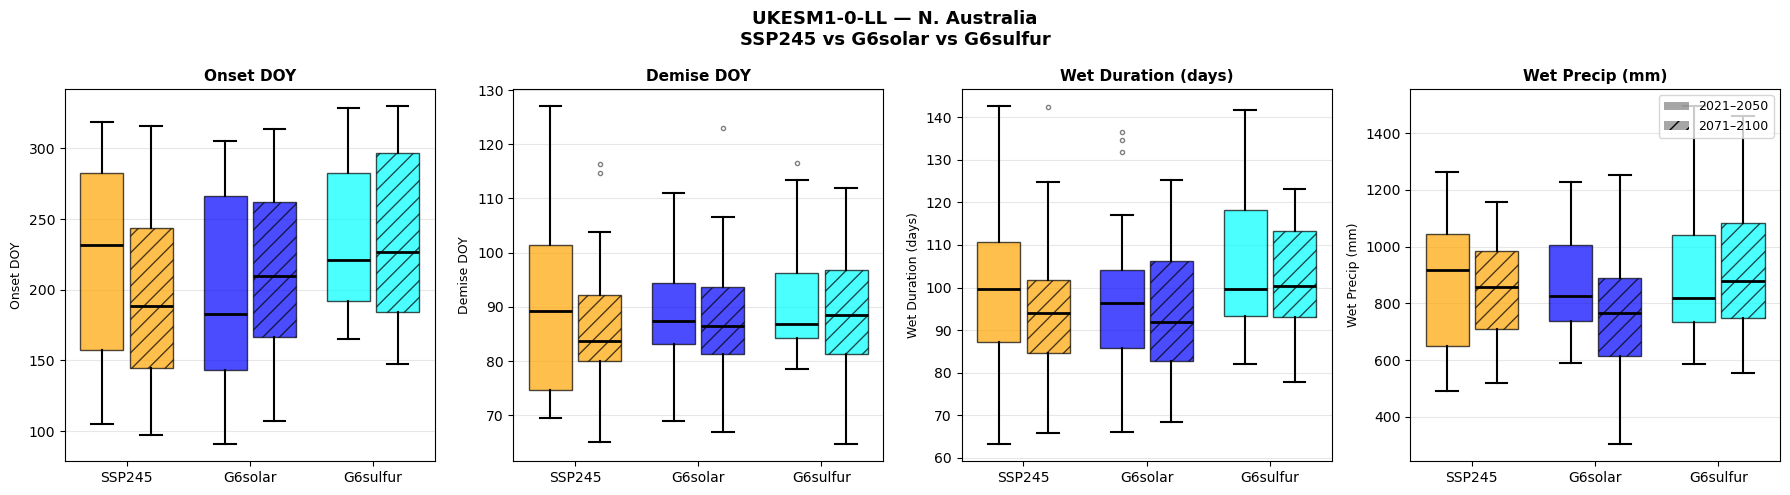

In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

base_dir = Path("~/UoE/20260218_Monsoons/rainyseason_output_files").expanduser()
missval  = -999.0

domains = {
    "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}

experiments = ["SSP245", "G6solar", "G6sulfur"]
exp_colors  = {"SSP245": "orange", "G6solar": "blue", "G6sulfur": "cyan"}

periods = ["2021-2050", "2071-2100"]
period_hatch = {"2021-2050": "", "2071-2100": "//"}

variables = {
    "onset_jday": "Onset DOY",
    "demise_jday": "Demise DOY",
    "durwet":     "Wet Duration (days)",
    "totwet":     "Wet Precip (mm)",
}

files = {
    ("SSP245",   "2021-2050"): "rainy_season_UKESM1-0-LL_SSP245_2021-2050.nc",
    ("SSP245",   "2071-2100"): "rainy_season_UKESM1-0-LL_SSP245_2071-2100.nc",
    ("G6solar",  "2021-2050"): "rainy_season_UKESM1-0-LL_G6solar_2021-2050.nc",
    ("G6solar",  "2071-2100"): "rainy_season_UKESM1-0-LL_G6solar_2071-2100.nc",
    ("G6sulfur", "2021-2050"): "rainy_season_UKESM1-0-LL_G6sulfur_2021-2050.nc",
    ("G6sulfur", "2071-2100"): "rainy_season_UKESM1-0-LL_G6sulfur_2071-2100.nc",
}

# Pre-load all datasets
dsets = {}
for key, fname in files.items():
    nc = base_dir / fname
    if nc.exists():
        dsets[key] = xr.open_dataset(nc)
    else:
        print(f"MISSING: {fname}")

# def get_annual_values(ds, ilat, ilon, key):
#     """Return spatial mean per year (1D array) with NaNs for missing."""
#     arr = ds[key].values[:, ilat, :][:, :, ilon].copy().astype(float)
#     arr[arr == missval] = np.nan
#     return np.nanmean(arr, axis=(1, 2))   # shape (nyrs,)

# ── One figure per region ─────────────────────────────────────────────────────
for region, dom in domains.items():

    # Get lat/lon indices (use SSP245 2021-2050 as reference grid)
    ref_ds = dsets[("SSP245", "2021-2050")]
    lats   = ref_ds.lat.values
    lons   = ref_ds.lon.values
    ilat   = np.where((lats >= dom["lat"][0]) & (lats <= dom["lat"][1]))[0]
    ilon   = np.where((lons >= dom["lon"][0]) & (lons <= dom["lon"][1]))[0]

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(f"UKESM1-0-LL — {region}\nSSP245 vs G6solar vs G6sulfur",
                 fontsize=13, fontweight="bold")

    for ax, (var_key, var_label) in zip(axes, variables.items()):

        # x positions: 3 experiments × 2 periods, grouped by experiment
        # Group centres at 1, 2, 3; within each group offset by ±0.2
        group_centres = {exp: i+1 for i, exp in enumerate(experiments)}
        offsets = {"2021-2050": -0.2, "2071-2100": +0.2}

        box_positions = []
        box_data      = []
        box_colors    = []
        box_hatches   = []

        for exp in experiments:
            for period in periods:
                key = (exp, period)
                if key not in dsets:
                    continue
                vals = get_annual_values(dsets[key], ilat, ilon, var_key)
                vals = vals[~np.isnan(vals)]

                pos = group_centres[exp] + offsets[period]
                box_positions.append(pos)
                box_data.append(vals)
                box_colors.append(exp_colors[exp])
                box_hatches.append(period_hatch[period])

        # Draw boxes
        bp = ax.boxplot(box_data, positions=box_positions,
                        widths=0.35, patch_artist=True,
                        medianprops={"color": "black", "linewidth": 2},
                        whiskerprops={"linewidth": 1.5},
                        capprops={"linewidth": 1.5},
                        flierprops={"marker": "o", "markersize": 3, "alpha": 0.5})

        for patch, color, hatch in zip(bp["boxes"], box_colors, box_hatches):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
            patch.set_hatch(hatch)

        ax.set_xticks(list(group_centres.values()))
        ax.set_xticklabels(experiments, fontsize=10)
        ax.set_title(var_label, fontsize=11, fontweight="bold")
        ax.set_ylabel(var_label, fontsize=9)
        ax.grid(True, axis="y", alpha=0.3)
        ax.set_xlim(0.5, len(experiments) + 0.5)

    # Legend
    legend_els = [
        mpatches.Patch(facecolor="grey", alpha=0.7,           label="2021–2050"),
        mpatches.Patch(facecolor="grey", alpha=0.7, hatch="//", label="2071–2100"),
    ]
    axes[-1].legend(handles=legend_els, fontsize=9, loc="upper right")

    plt.tight_layout()
    safe_region = region.replace(" ", "_").replace(".", "")
    outpng = base_dir / f"UKESM1-0-LL_boxplot_{safe_region}.png"
    # plt.savefig(outpng, dpi=150, bbox_inches="tight")
    plt.show()
    # print(f"Saved → {outpng.name}")

for ds in dsets.values():
    ds.close()

In [6]:
# ds = dsets[("SSP245", "2021-2050")]
# durwet_raw = ds["durwet"].values.astype(float)
# durwet_raw[durwet_raw == missval] = np.nan
# print(f"durwet max : {np.nanmax(durwet_raw):.2f}")
# print(f"durwet min : {np.nanmin(durwet_raw):.2f}")
# print(f"values > 400: {np.unique(durwet_raw[durwet_raw > 400])}")

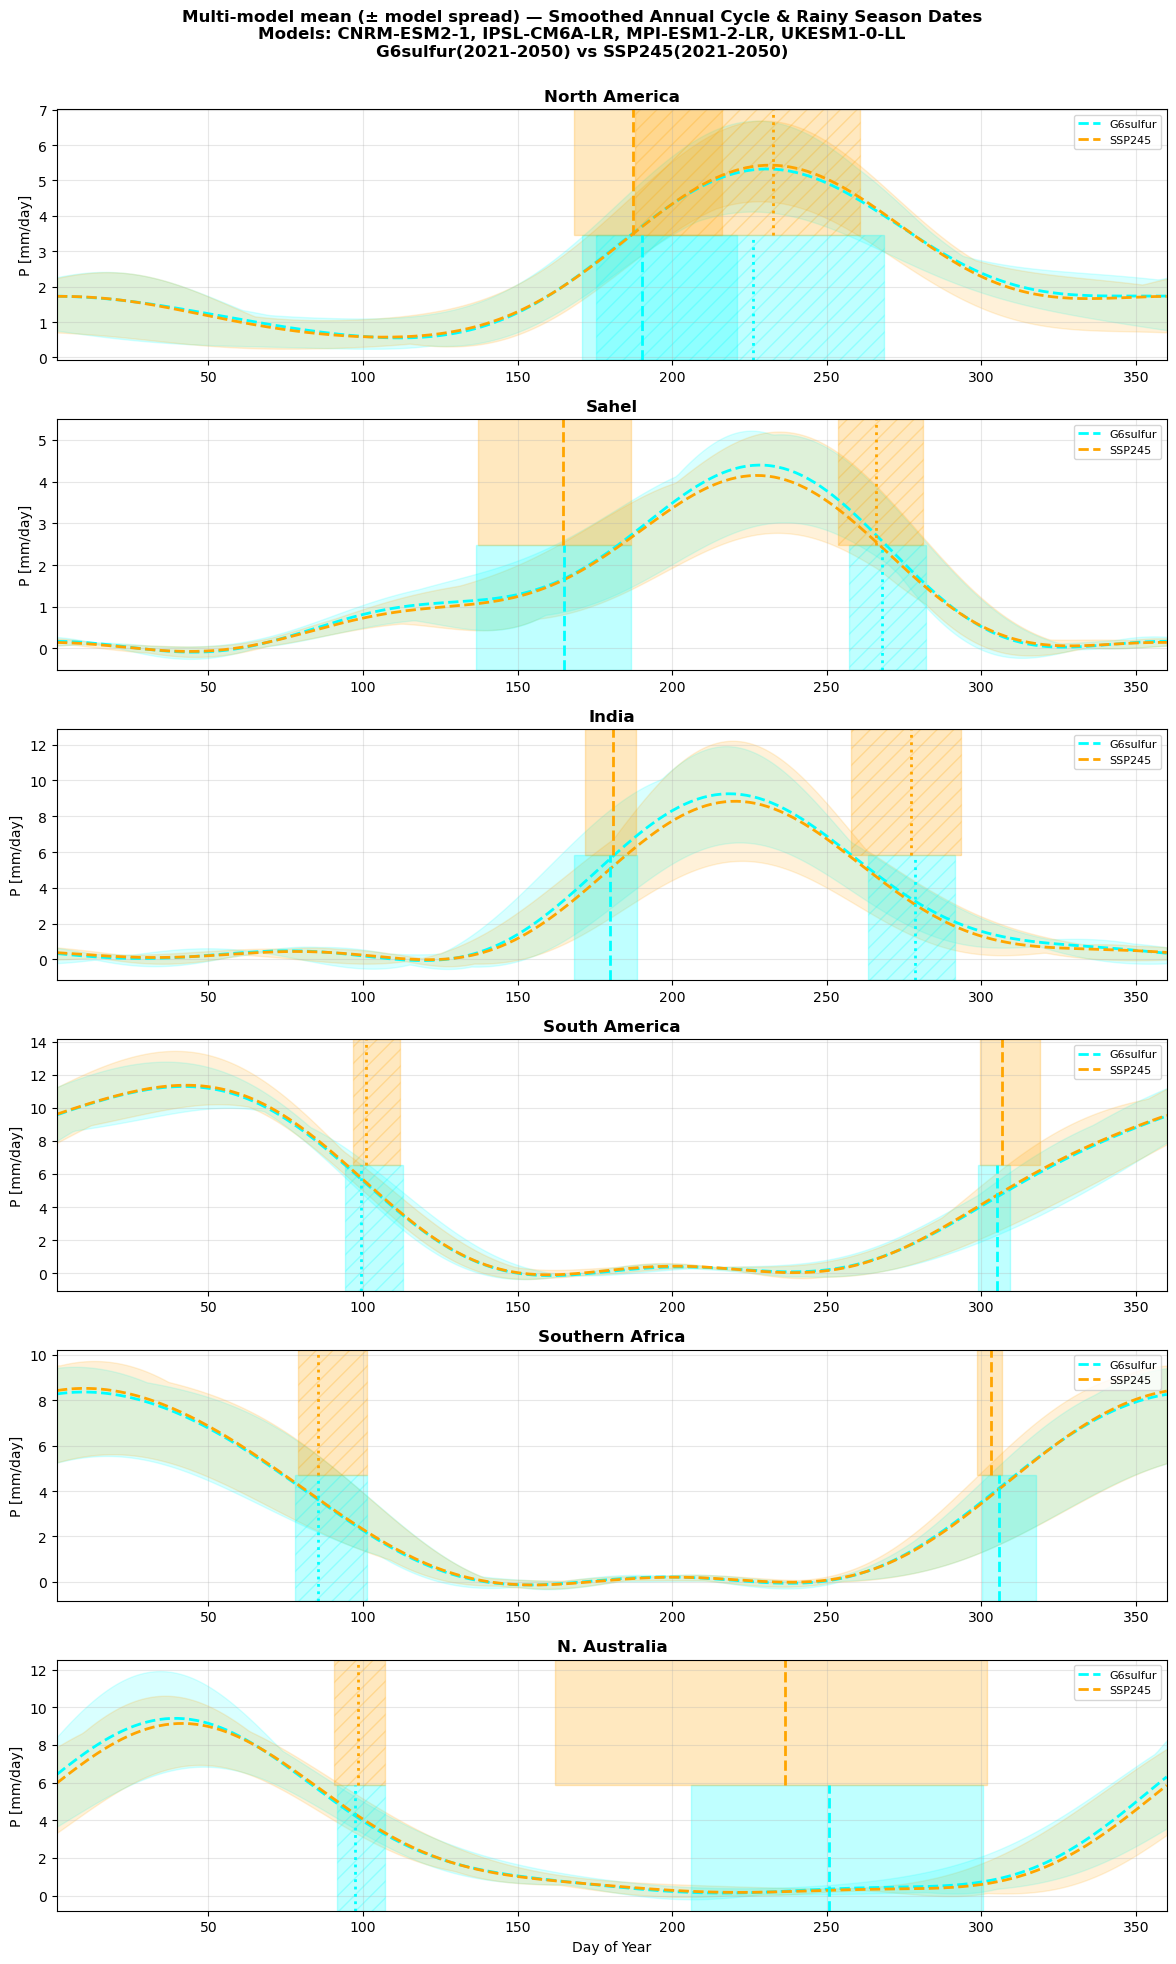

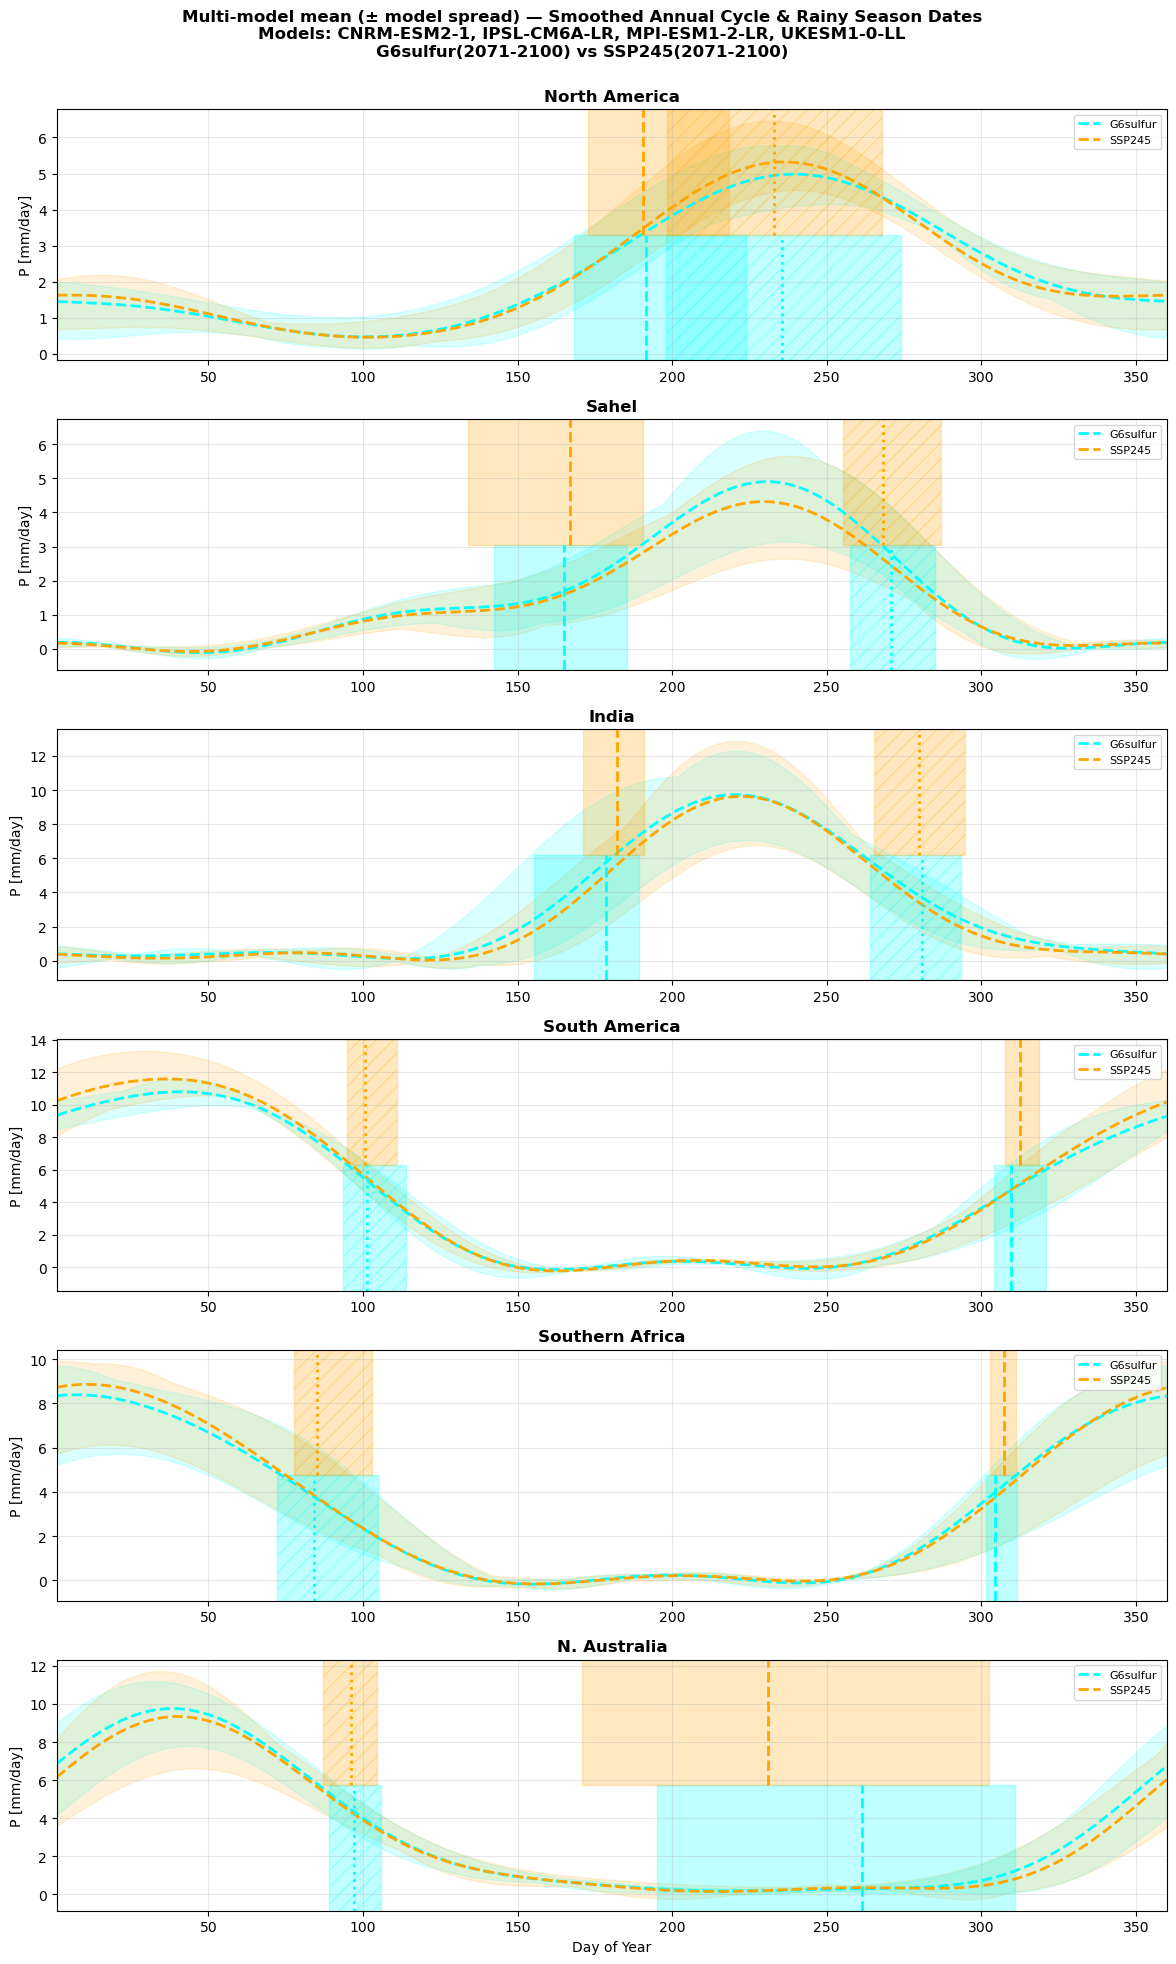

In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

base_dir = Path("~/UoE/20260218_Monsoons/rainyseason_output_files").expanduser()
missval  = -999.0

models = [
    "CNRM-ESM2-1",
    "IPSL-CM6A-LR",
    "MPI-ESM1-2-LR",
    "UKESM1-0-LL",
]

# Scenarios and their colours — filenames will be constructed per model
scenarios = [
    # ("HIST",     "black"),
    # ("G6solar",  "blue"),
    ("G6sulfur", "cyan"),
    ("SSP245",   "orange"),
    # ("SSP585",   "red"),
]

period_files = {
    # "HIST":     "1985-2014",
    # "G6solar":  None,   # filled per group
    "G6sulfur": None,
    "SSP245":   None,
    # "SSP585":   None,
}

groups = {
    "2021-2050": {scen: ("1985-2014" if scen == "HIST" else "2021-2050") for scen, _ in scenarios},
    "2071-2100": {scen: ("1985-2014" if scen == "HIST" else "2071-2100") for scen, _ in scenarios},
}

domains = {
    "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}

def load_region(nc_file, dom, missval):
    """Load spatially averaged smoothed_cycle, onset_jday, demise_jday for a region."""
    ds   = xr.open_dataset(nc_file)
    lats = ds.lat.values
    lons = ds.lon.values
    ilat = np.where((lats >= dom["lat"][0]) & (lats <= dom["lat"][1]))[0]
    ilon = np.where((lons >= dom["lon"][0]) & (lons <= dom["lon"][1]))[0]

    sc = ds["smoothed_cycle"].values[:, ilat, :][:, :, ilon]
    sc = np.nanmean(sc, axis=(1, 2))          # shape: (doy,)

    results = {"sc": sc}
    for key in ["onset_jday", "demise_jday"]:
        arr    = ds[key].values[:, ilat, :][:, :, ilon].astype(float)
        arr[arr == missval] = np.nan
        yearly = np.nanmean(arr, axis=(1, 2)) # shape: (years,)
        n      = np.sum(~np.isnan(yearly))
        mu     = np.nanmean(yearly)
        se     = np.nanstd(yearly) / np.sqrt(n) if n > 1 else 0.0
        results[key] = {"mu": mu, "se": se, "yearly": yearly}

    ds.close()
    return results


for group_label, scen_periods in groups.items():
    n_exp = len(scenarios)
    n_dom = len(domains)
    fig, axes = plt.subplots(n_dom, 1, figsize=(12, 20))

    for ax, (region, dom) in zip(axes.flat, domains.items()):
        lines = []
        strip_data = []

        for i, (scen, color) in enumerate(scenarios):
            period = scen_periods[scen]
            fname_template = f"rainy_season_{{model}}_{scen}_{period}.nc"

            # ── Collect data across models ────────────────────────────────
            all_sc      = []
            all_onset   = []
            all_demise  = []

            for model in models:
                nc_file = base_dir / fname_template.format(model=model)
                if not nc_file.exists():
                    print(f"  SKIP {nc_file.name}")
                    continue
                try:
                    r = load_region(nc_file, dom, missval)
                except Exception as e:
                    print(f"  ERROR {nc_file.name}: {e}")
                    continue

                all_sc.append(r["sc"])
                all_onset.append(r["onset_jday"]["mu"])
                all_demise.append(r["demise_jday"]["mu"])

            if not all_sc:
                continue

            # ── Harmonise DOY length then stack ──────────────────────────
            target_doys = 360
            all_sc_interp = []
            for sc_arr in all_sc:
                if len(sc_arr) == target_doys:
                    all_sc_interp.append(sc_arr)
                else:
                    src = np.linspace(0, 1, len(sc_arr))
                    dst = np.linspace(0, 1, target_doys)
                    all_sc_interp.append(np.interp(dst, src, sc_arr))

            all_sc     = np.array(all_sc_interp)  # (n_models, 360)
            all_onset  = np.array(all_onset)       # (n_models,)
            all_demise = np.array(all_demise)      # (n_models,)

            doys = np.arange(1, target_doys + 1)

            # ── Multi-model statistics ────────────────────────────────────
            sc_mean = np.nanmean(all_sc, axis=0)
            sc_min  = np.nanmin(all_sc,  axis=0)
            sc_max  = np.nanmax(all_sc,  axis=0)

            onset_mu  = np.nanmean(all_onset)
            onset_min = np.nanmin(all_onset);  onset_max = np.nanmax(all_onset)

            demise_mu  = np.nanmean(all_demise)
            demise_min = np.nanmin(all_demise); demise_max = np.nanmax(all_demise)
            

            # ── Plot mean line + model-spread shading ─────────────────────
            ls   = "-" if scen == "HIST" else "--"
            line, = ax.plot(doys, sc_mean, color=color, linewidth=2,
                            label=scen, linestyle=ls)
            ax.fill_between(doys, sc_min, sc_max,
                            color=color, alpha=0.15)
            lines.append(line)

            strip_data.append((i, color,
                               onset_mu,  onset_min,  onset_max,
                               demise_mu, demise_min, demise_max))

        # ── Onset / demise strips ─────────────────────────────────────────
        ax.set_title(region, fontsize=12, fontweight="bold")
        # ax.set_xlabel("Day of Year")
        ax.set_ylabel("P [mm/day]")
        ax.set_xlim(1, 360)
        ax.grid(True, alpha=0.3)

        ylo, yhi = ax.get_ylim()
        strip_h  = (yhi - ylo) / n_exp

        for (i, color,
             onset_mu,  onset_min,  onset_max,
             demise_mu, demise_min, demise_max) in strip_data:

            ybot = ylo + i * strip_h
            ytop = ybot + strip_h
            yfrac_bot = (ybot - ylo) / (yhi - ylo)
            yfrac_top = (ytop - ylo) / (yhi - ylo)

            # Onset — model spread as span, mean as dashed line
            ax.axvspan(onset_min, onset_max,
                       ymin=yfrac_bot, ymax=yfrac_top,
                       alpha=0.25, color=color)
            ax.axvline(onset_mu,
                       ymin=yfrac_bot, ymax=yfrac_top,
                       color=color, linewidth=2, linestyle="--")

            # Demise — model spread as span (hatched), mean as dotted line
            ax.axvspan(demise_min, demise_max,
                       ymin=yfrac_bot, ymax=yfrac_top,
                       alpha=0.25, color=color, hatch="//")
            ax.axvline(demise_mu,
                       ymin=yfrac_bot, ymax=yfrac_top,
                       color=color, linewidth=2, linestyle=":")

        ax.legend(handles=lines, fontsize=8, loc="upper right")

    # axes[0].legend(handles=lines, fontsize=8, loc="upper right", ncol=2)
    axes[-1].set_xlabel("Day of Year")

    plt.suptitle(
        f"Multi-model mean (± model spread) — Smoothed Annual Cycle & Rainy Season Dates\n"
        f"Models: {', '.join(models)}\n"
        # f"HIST (1985–2014) vs {group_label}",
        # f"HIST (1985–2014) vs {scenarios[-1][0]}({group_label})",
        f"{scenarios[0][0]}({group_label}) vs {scenarios[-1][0]}({group_label})",
        fontsize=12, fontweight="bold"
    )
    # plt.tight_layout()
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    outpng = base_dir / f"multimodel_annual_cycle_comparison_{group_label}.png"
    # plt.savefig(outpng, dpi=150, bbox_inches="tight")
    plt.show()
    # print(f"Saved → {outpng.name}")

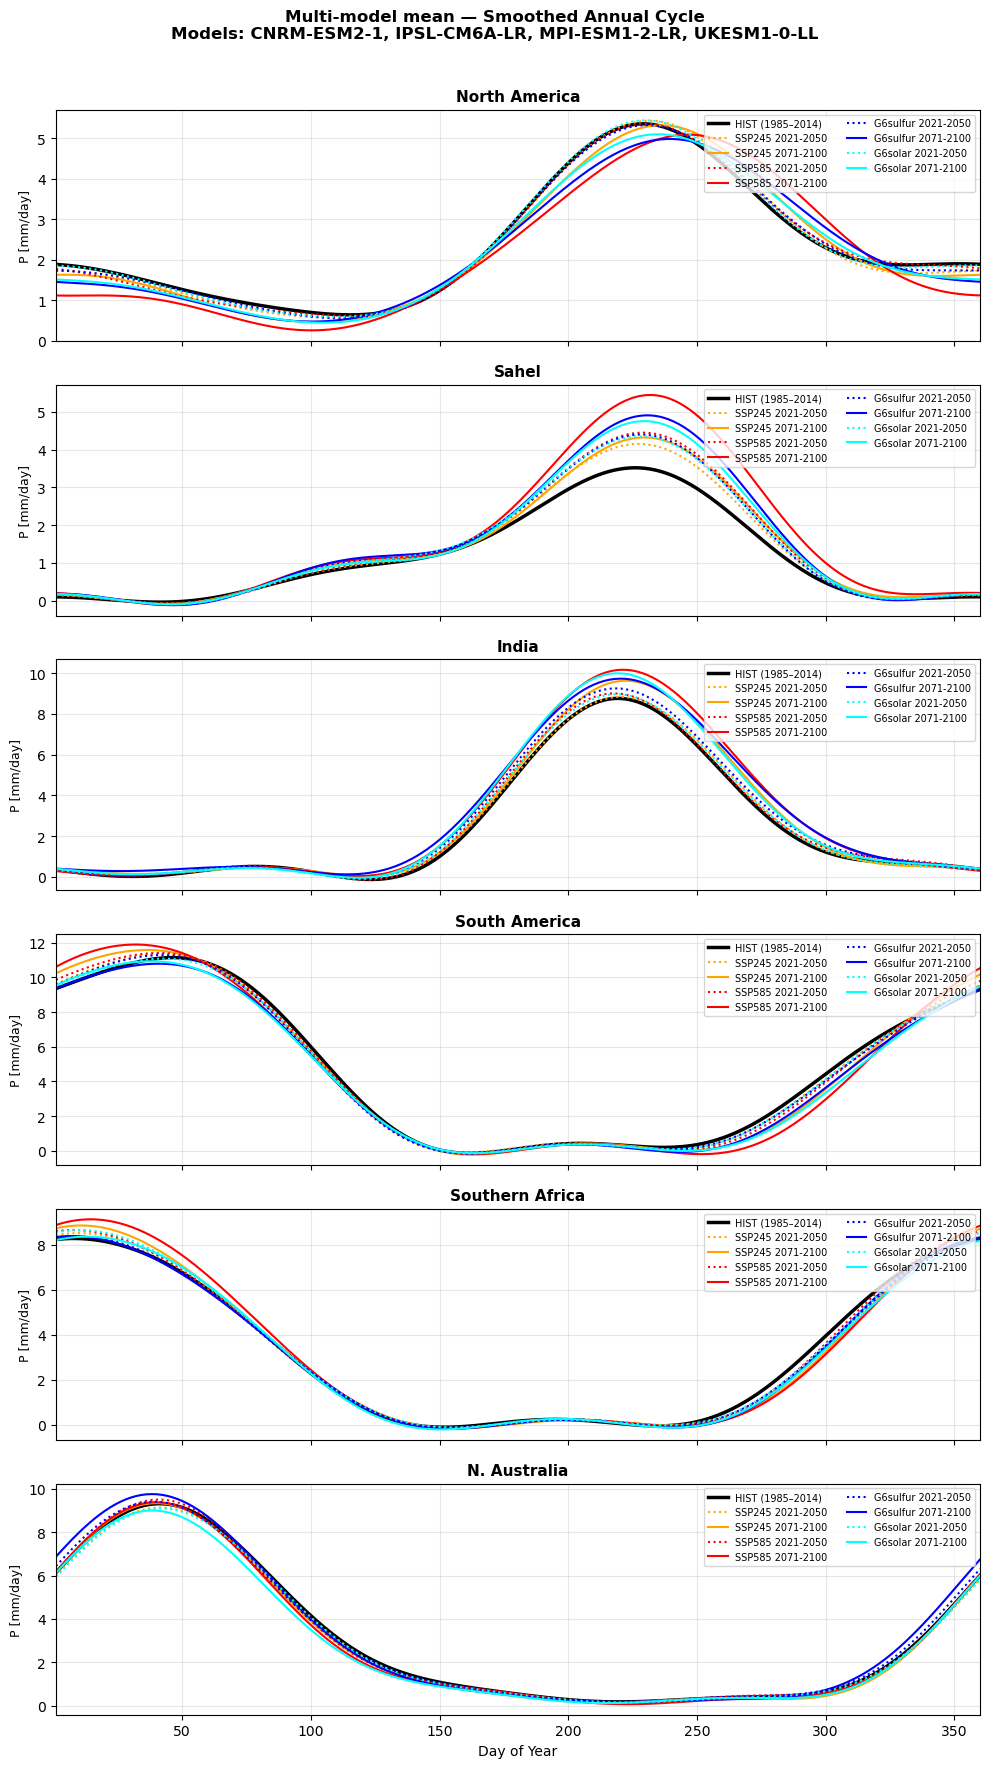

In [9]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

base_dir = Path("~/UoE/20260218_Monsoons/rainyseason_output_files").expanduser()
missval  = -999.0

models = [
    "CNRM-ESM2-1",
    "IPSL-CM6A-LR",
    "MPI-ESM1-2-LR",
    "UKESM1-0-LL",
]

scenarios = [
    ("SSP245",   "orange"),
    ("SSP585",   "red"),
    ("G6sulfur", "blue"),
    ("G6solar",  "cyan"),
]

domains = {
    "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}

target_doys = 360
doys = np.arange(1, target_doys + 1)

def load_sc(nc_file, dom):
    """Return spatially averaged smoothed_cycle interpolated to target_doys."""
    ds   = xr.open_dataset(nc_file)
    lats = ds.lat.values
    lons = ds.lon.values
    ilat = np.where((lats >= dom["lat"][0]) & (lats <= dom["lat"][1]))[0]
    ilon = np.where((lons >= dom["lon"][0]) & (lons <= dom["lon"][1]))[0]
    sc   = ds["smoothed_cycle"].values[:, ilat, :][:, :, ilon]
    sc   = np.nanmean(sc, axis=(1, 2))   # (doy,)
    ds.close()
    if len(sc) != target_doys:
        src = np.linspace(0, 1, len(sc))
        dst = np.linspace(0, 1, target_doys)
        sc  = np.interp(dst, src, sc)
    return sc

def multimodel_mean(model_list, fname_template, dom):
    """Collect per-model sc and return multi-model mean (None if no files found)."""
    all_sc = []
    for model in model_list:
        nc_file = base_dir / fname_template.format(model=model)
        if not nc_file.exists():
            print(f"  SKIP {nc_file.name}")
            continue
        try:
            all_sc.append(load_sc(nc_file, dom))
        except Exception as e:
            print(f"  ERROR {nc_file.name}: {e}")
    if not all_sc:
        return None
    return np.nanmean(np.array(all_sc), axis=0)


n_dom = len(domains)
fig, axes = plt.subplots(n_dom, 1, figsize=(10, 18), sharex=True)

for ax, (region, dom) in zip(axes.flat, domains.items()):
    lines = []

    # ── HIST (thick solid black) ──────────────────────────────────────────
    hist_template = "rainy_season_{model}_HIST_1985-2014.nc"
    hist_mean = multimodel_mean(models, hist_template, dom)
    if hist_mean is not None:
        line, = ax.plot(doys, hist_mean, color="black", linewidth=2.5,
                        linestyle="-", label="HIST (1985–2014)")
        lines.append(line)

    # ── Future scenarios ──────────────────────────────────────────────────
    for scen, color in scenarios:
        for period, ls in [("2021-2050", ":"), ("2071-2100", "-")]:
            template = f"rainy_season_{{model}}_{scen}_{period}.nc"
            sc_mean  = multimodel_mean(models, template, dom)
            if sc_mean is None:
                continue
            line, = ax.plot(doys, sc_mean, color=color, linewidth=1.5,
                            linestyle=ls,
                            label=f"{scen} {period}")
            lines.append(line)

    ax.set_title(region, fontsize=11, fontweight="bold")
    ax.set_ylabel("P [mm/day]", fontsize=9)
    ax.set_xlim(1, 360)
    ax.grid(True, alpha=0.3)
    ax.legend(handles=lines, fontsize=7, loc="upper right", ncol=2)

axes[-1].set_xlabel("Day of Year", fontsize=10)

plt.suptitle(
    "Multi-model mean — Smoothed Annual Cycle\n"
    f"Models: {', '.join(models)}",
    fontsize=12, fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 1, 0.97])

outpng = base_dir / "multimodel_annual_cycle_allscenarios.png"
# plt.savefig(outpng, dpi=150, bbox_inches="tight")
plt.show()
# print(f"Saved → {outpng.name}")

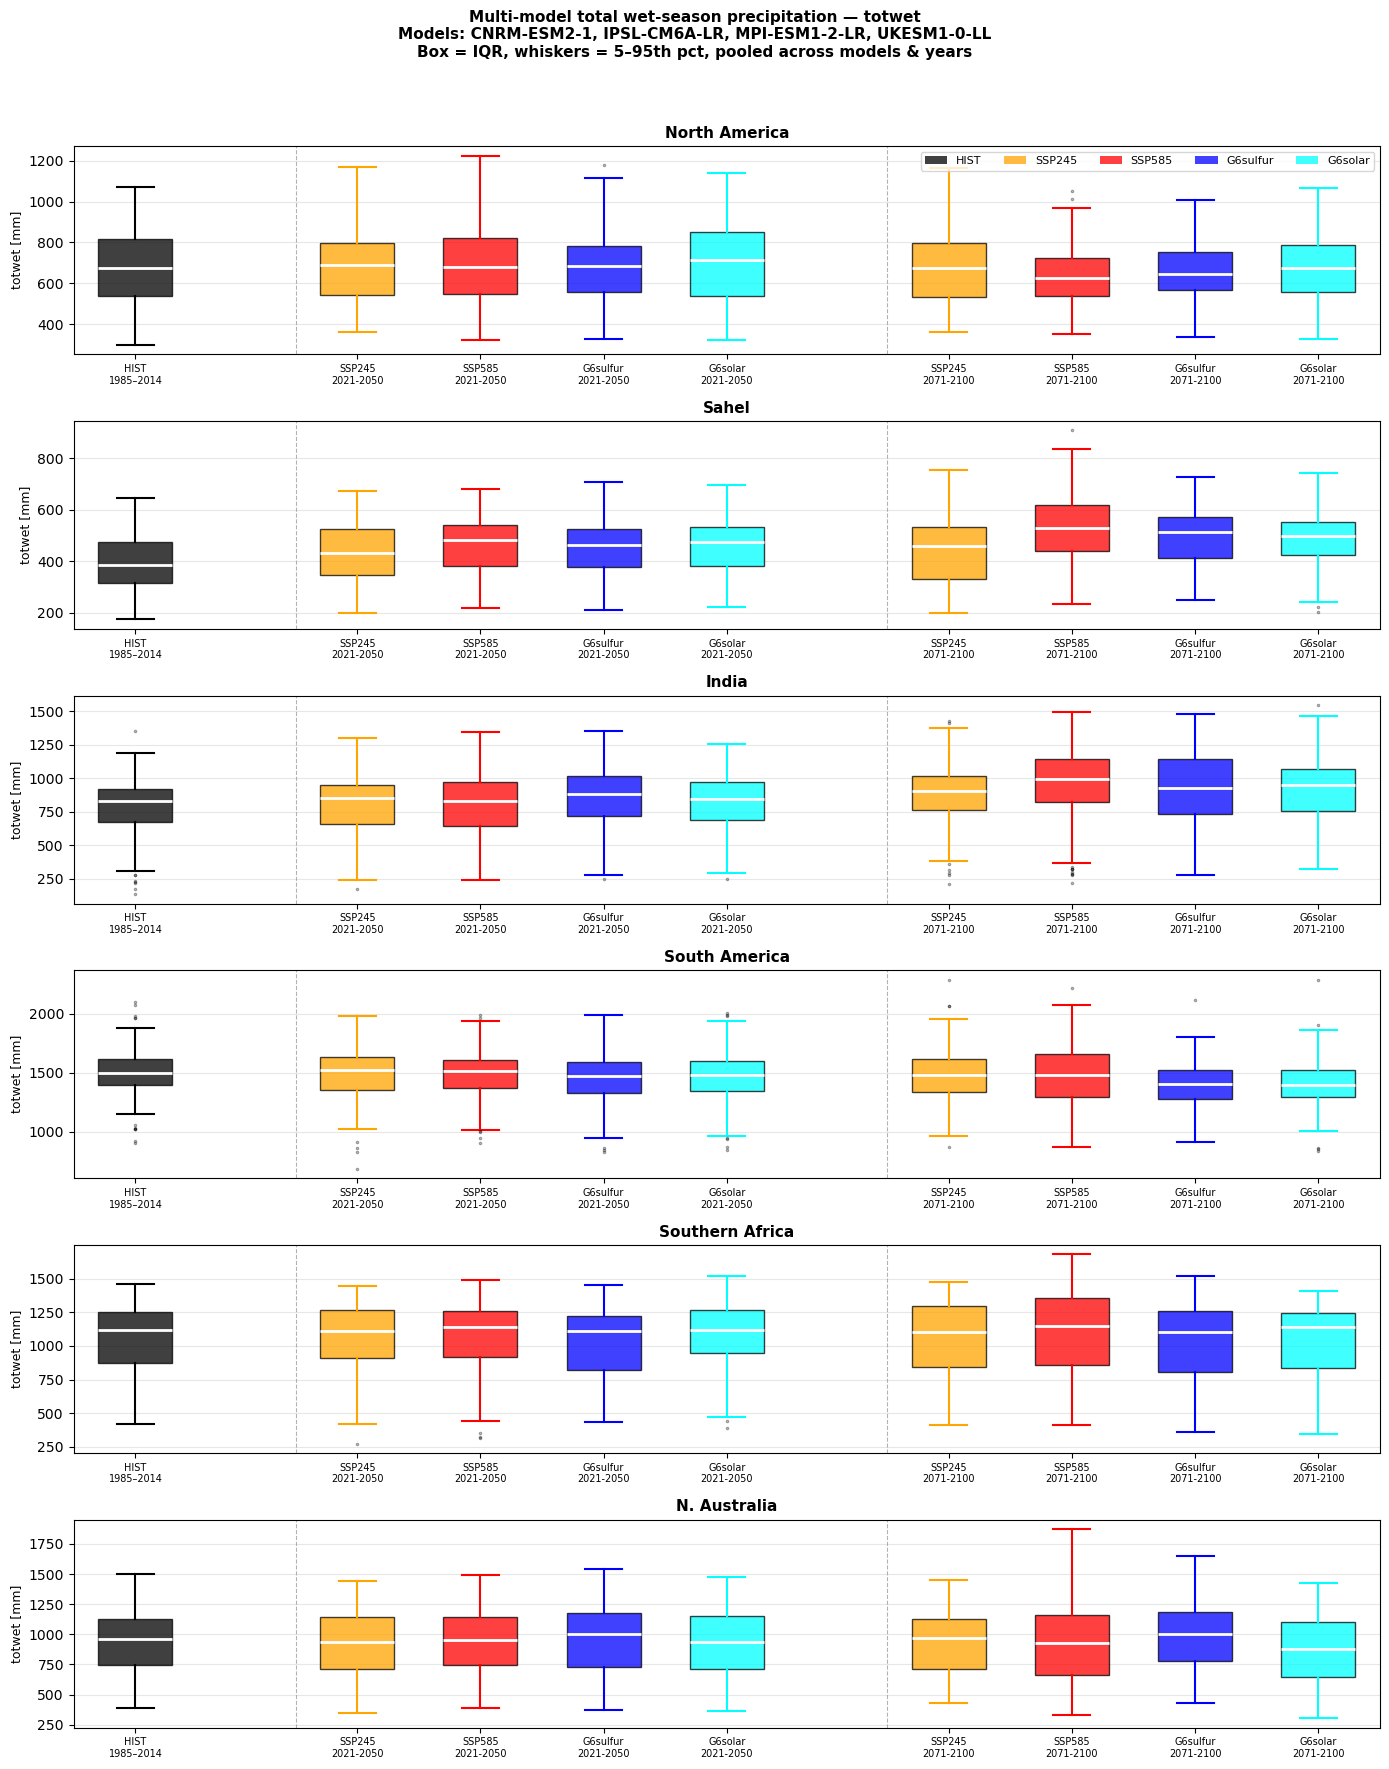

Saved → multimodel_totwet_boxwhisker.png


In [10]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

base_dir = Path("~/UoE/20260218_Monsoons/rainyseason_output_files").expanduser()
missval  = -999.0

models = [
    "CNRM-ESM2-1",
    "IPSL-CM6A-LR",
    "MPI-ESM1-2-LR",
    "UKESM1-0-LL",
]

# Order and colours for the x-axis groups
scenario_styles = {
    "HIST":     "black",
    "SSP245":   "orange",
    "SSP585":   "red",
    "G6sulfur": "blue",
    "G6solar":  "cyan",
}

domains = {
    "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}

def load_totwet(nc_file, dom):
    """Return spatially averaged totwet, shape (years,). Returns None on failure."""
    ds   = xr.open_dataset(nc_file)
    lats = ds.lat.values
    lons = ds.lon.values
    ilat = np.where((lats >= dom["lat"][0]) & (lats <= dom["lat"][1]))[0]
    ilon = np.where((lons >= dom["lon"][0]) & (lons <= dom["lon"][1]))[0]
    arr  = ds["totwet"].values[:, ilat, :][:, :, ilon].astype(float)
    arr[arr == missval] = np.nan
    spatial_mean = np.nanmean(arr, axis=(1, 2))   # (years,)
    ds.close()
    return spatial_mean

def collect_pool(scenario, period, dom):
    """Pool totwet values across all models (and all years) for one scenario/period/region."""
    pool = []
    fname_t = f"rainy_season_{{model}}_{scenario}_{period}.nc"
    for model in models:
        nc_file = base_dir / fname_t.format(model=model)
        if not nc_file.exists():
            print(f"  SKIP {nc_file.name}")
            continue
        try:
            vals = load_totwet(nc_file, dom)
            pool.append(vals[~np.isnan(vals)])
        except Exception as e:
            print(f"  ERROR {nc_file.name}: {e}")
    if not pool:
        return None
    return np.concatenate(pool)


# ── Build the box layout ───────────────────────────────────────────────────
# x-axis order: HIST | SSP245-near SSP585-near G6sulfur-near G6solar-near |
#                       SSP245-far  SSP585-far  G6sulfur-far  G6solar-far
future_scens = ["SSP245", "SSP585", "G6sulfur", "G6solar"]
periods      = [("2021-2050", "near", ":"), ("2071-2100", "far", "-")]

# Assign x positions with a small gap between HIST, near-term, far-term groups
gap   = 0.8
x_pos = {}
x     = 1.0
x_pos["HIST"] = x

x += 1.0 + gap
for scen in future_scens:
    x_pos[(scen, "2021-2050")] = x
    x += 1.0

x += gap
for scen in future_scens:
    x_pos[(scen, "2071-2100")] = x
    x += 1.0


n_dom = len(domains)
fig, axes = plt.subplots(n_dom, 1, figsize=(14, 18), sharex=False)

for ax, (region, dom) in zip(axes.flat, domains.items()):

    boxes      = []
    positions  = []
    colors     = []
    xtick_pos  = []
    xtick_lab  = []

    # HIST
    pool = collect_pool("HIST", "1985-2014", dom)
    if pool is not None and len(pool) > 0:
        boxes.append(pool)
        positions.append(x_pos["HIST"])
        colors.append(scenario_styles["HIST"])
        xtick_pos.append(x_pos["HIST"])
        xtick_lab.append("HIST\n1985–2014")

    # Future scenarios, near then far
    for period_str, period_tag, _ in periods:
        for scen in future_scens:
            pool = collect_pool(scen, period_str, dom)
            if pool is not None and len(pool) > 0:
                boxes.append(pool)
                positions.append(x_pos[(scen, period_str)])
                colors.append(scenario_styles[scen])
                xtick_pos.append(x_pos[(scen, period_str)])
                xtick_lab.append(f"{scen}\n{period_str}")

    # Draw box-whiskers
    bp = ax.boxplot(boxes, positions=positions, widths=0.6,
                    patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker=".", markersize=3, alpha=0.4),
                    showfliers=True)

    for patch, col in zip(bp["boxes"], colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)
    for whisker, cap, col in zip(
            bp["whiskers"][::2], bp["caps"][::2], colors):
        whisker.set_color(col); cap.set_color(col)
    for whisker, cap, col in zip(
            bp["whiskers"][1::2], bp["caps"][1::2], colors):
        whisker.set_color(col); cap.set_color(col)

    # Vertical separators between HIST / near / far groups
    near_start = x_pos[("SSP245", "2021-2050")] - 0.5
    far_start  = x_pos[("SSP245", "2071-2100")] - 0.5
    for xv in [near_start, far_start]:
        ax.axvline(xv, color="grey", linewidth=0.8, linestyle="--", alpha=0.6)

    ax.set_xticks(xtick_pos)
    ax.set_xticklabels(xtick_lab, fontsize=7)
    ax.set_title(region, fontsize=11, fontweight="bold")
    ax.set_ylabel("totwet [mm]", fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)

# ── Legend ────────────────────────────────────────────────────────────────
legend_patches = [mpatches.Patch(facecolor=c, alpha=0.75, label=s)
                  for s, c in scenario_styles.items()]
axes[0].legend(handles=legend_patches, fontsize=8, loc="upper right", ncol=5)

plt.suptitle(
    "Multi-model total wet-season precipitation — totwet\n"
    f"Models: {', '.join(models)}\n"
    "Box = IQR, whiskers = 5–95th pct, pooled across models & years",
    fontsize=11, fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 1, 0.96])

outpng = base_dir / "multimodel_totwet_boxwhisker.png"
plt.savefig(outpng, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {outpng.name}")

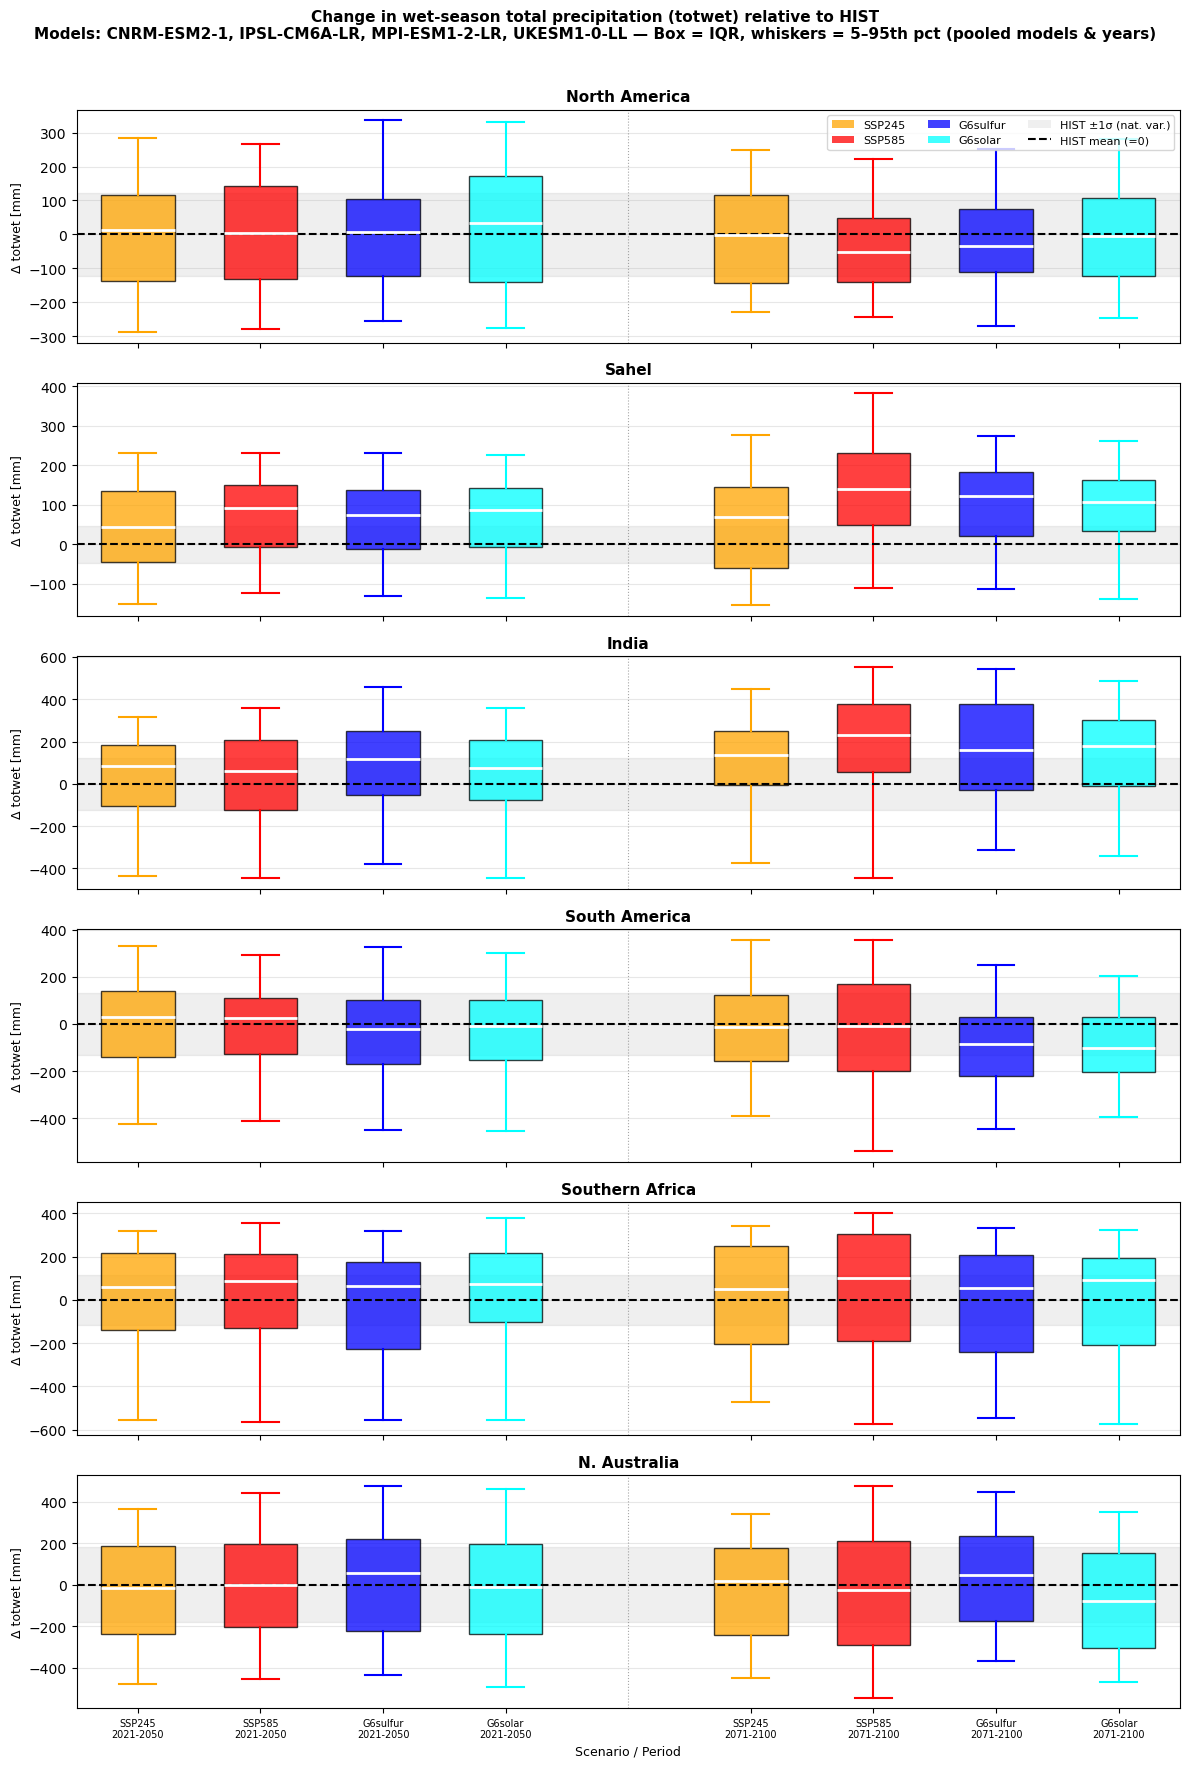

Saved → multimodel_totwet_anomaly_boxwhisker.png


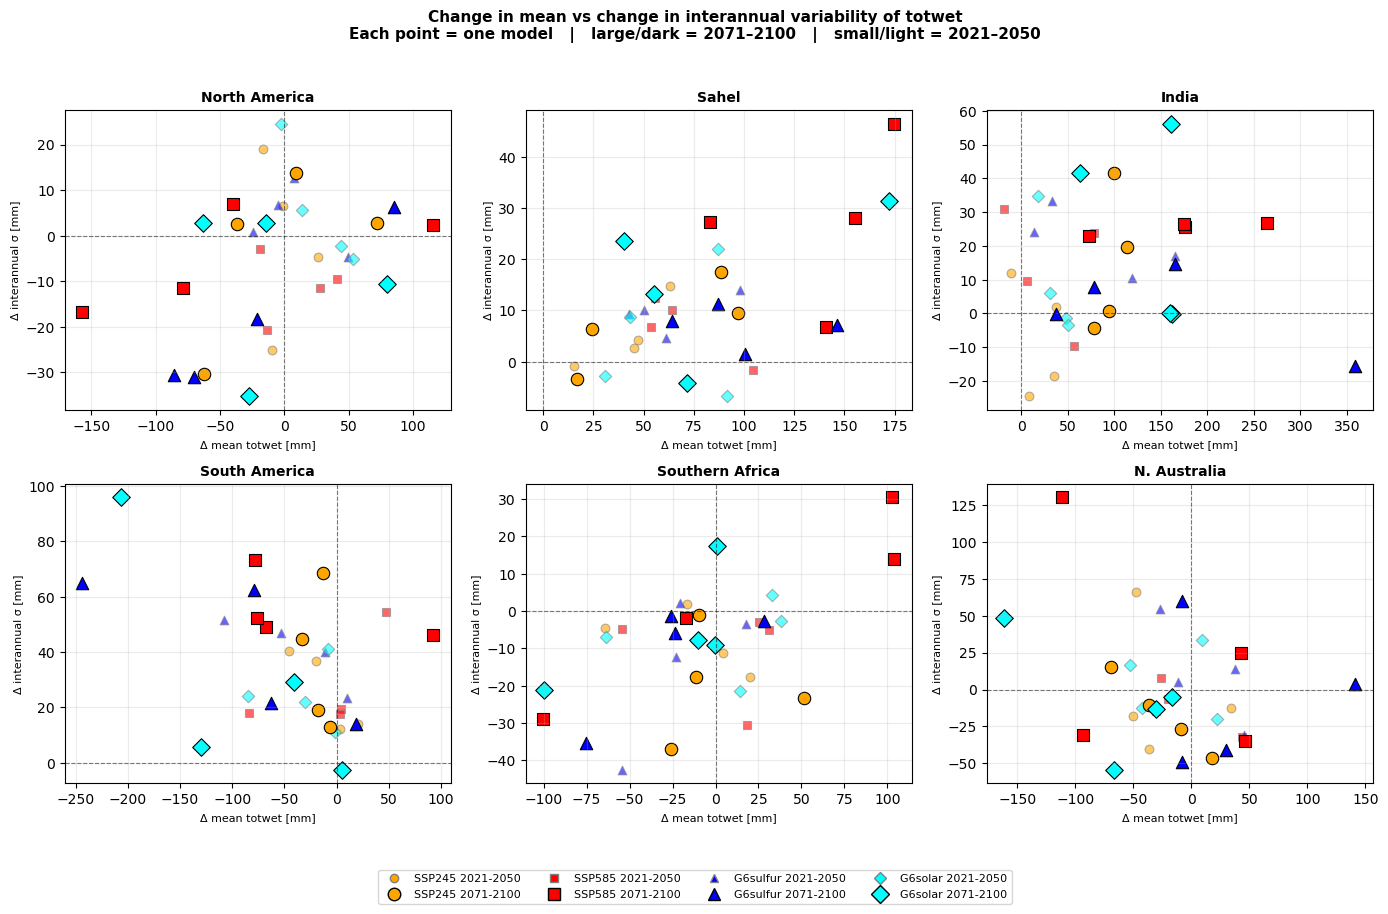

Saved → multimodel_totwet_change_vs_variability_scatter.png


In [11]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

base_dir = Path("~/UoE/20260218_Monsoons/rainyseason_output_files").expanduser()
missval  = -999.0

models = [
    "CNRM-ESM2-1",
    "IPSL-CM6A-LR",
    "MPI-ESM1-2-LR",
    "UKESM1-0-LL",
]

future_scens = ["SSP245", "SSP585", "G6sulfur", "G6solar"]
periods      = ["2021-2050", "2071-2100"]

scenario_styles = {
    "SSP245":   {"color": "orange", "marker": "o"},
    "SSP585":   {"color": "red",    "marker": "s"},
    "G6sulfur": {"color": "blue",   "marker": "^"},
    "G6solar":  {"color": "cyan",   "marker": "D"},
}

period_styles = {
    "2021-2050": {"linestyle": "none", "alpha": 0.6},
    "2071-2100": {"linestyle": "none", "alpha": 1.0},
}

domains = {
    "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}


def load_totwet(nc_file, dom):
    """Spatially averaged totwet, shape (years,)."""
    ds   = xr.open_dataset(nc_file)
    lats = ds.lat.values
    lons = ds.lon.values
    ilat = np.where((lats >= dom["lat"][0]) & (lats <= dom["lat"][1]))[0]
    ilon = np.where((lons >= dom["lon"][0]) & (lons <= dom["lon"][1]))[0]
    arr  = ds["totwet"].values[:, ilat, :][:, :, ilon].astype(float)
    arr[arr == missval] = np.nan
    ds.close()
    return np.nanmean(arr, axis=(1, 2))   # (years,)


def get_model_stats(scenario, period, dom):
    """
    Returns per-model (mean, std) of spatially averaged totwet.
    Shape: (n_models,), (n_models,)
    """
    means, stds = [], []
    fname_t = f"rainy_season_{{model}}_{scenario}_{period}.nc"
    for model in models:
        nc_file = base_dir / fname_t.format(model=model)
        if not nc_file.exists():
            print(f"  SKIP {nc_file.name}")
            continue
        try:
            vals = load_totwet(nc_file, dom)
            vals = vals[~np.isnan(vals)]
            means.append(np.mean(vals))
            stds.append(np.std(vals, ddof=1))
        except Exception as e:
            print(f"  ERROR {nc_file.name}: {e}")
    return np.array(means), np.array(stds)


# ── Pre-compute HIST per-model stats for all domains ──────────────────────
hist_means_all = {}   # {region: array (n_models,)}
hist_stds_all  = {}

for region, dom in domains.items():
    hm, hs = get_model_stats("HIST", "1985-2014", dom)
    hist_means_all[region] = hm
    hist_stds_all[region]  = hs

hist_ref_mean = {r: np.mean(hist_means_all[r]) for r in domains}
hist_ref_std  = {r: np.mean(hist_stds_all[r])  for r in domains}


# ═══════════════════════════════════════════════════════════════════════════
# PLOT 1 — Anomaly box-whisker
# ═══════════════════════════════════════════════════════════════════════════
# Box layout: for each region one row of boxes:
#   [near: SSP245 SSP585 G6sulfur G6solar] gap [far: SSP245 SSP585 G6sulfur G6solar]
gap       = 1.0
n_scen    = len(future_scens)
near_xs   = np.arange(1, n_scen + 1, dtype=float)
far_xs    = near_xs + n_scen + gap
all_xs    = np.concatenate([near_xs, far_xs])

n_dom = len(domains)
fig1, axes1 = plt.subplots(n_dom, 1, figsize=(12, 18), sharex=True)

for ax, (region, dom) in zip(axes1.flat, domains.items()):
    ref_mean = hist_ref_mean[region]

    boxes, positions, colors = [], [], []
    xtick_pos, xtick_lab = [], []

    for period, xs in [("2021-2050", near_xs), ("2071-2100", far_xs)]:
        for scen, x in zip(future_scens, xs):
            fname_t = f"rainy_season_{{model}}_{scen}_{period}.nc"
            pool = []
            for model in models:
                nc_file = base_dir / fname_t.format(model=model)
                if not nc_file.exists():
                    continue
                try:
                    vals = load_totwet(nc_file, dom)
                    pool.append(vals[~np.isnan(vals)])
                except Exception:
                    continue
            if not pool:
                continue
            anomalies = np.concatenate(pool) - ref_mean
            boxes.append(anomalies)
            positions.append(x)
            colors.append(scenario_styles[scen]["color"])
            xtick_pos.append(x)
            xtick_lab.append(f"{scen}\n{period}")

    bp = ax.boxplot(boxes, positions=positions, widths=0.6,
                    patch_artist=True, whis=[5, 95],
                    medianprops=dict(color="white", linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3),
                    showfliers=False)

    for patch, col in zip(bp["boxes"], colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)
    for w, c_col in zip(bp["whiskers"], np.repeat(colors, 2)):
        w.set_color(c_col)
    for c, c_col in zip(bp["caps"], np.repeat(colors, 2)):
        c.set_color(c_col)

    # Zero line = HIST mean
    ax.axhline(0, color="black", linewidth=1.5, linestyle="--", label="HIST mean")

    # Separator between near and far
    ax.axvline((near_xs[-1] + far_xs[0]) / 2,
               color="grey", linewidth=0.8, linestyle=":", alpha=0.7)

    # HIST interannual std as grey band around zero
    h_std = hist_ref_std[region]
    ax.axhspan(-h_std, h_std, color="grey", alpha=0.12, label="HIST ±1σ")

    ax.set_title(region, fontsize=11, fontweight="bold")
    ax.set_ylabel("Δ totwet [mm]", fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)

axes1[-1].set_xticks(xtick_pos)
axes1[-1].set_xticklabels(xtick_lab, fontsize=7)
axes1[-1].set_xlabel("Scenario / Period", fontsize=9)

# Shared legend
legend_patches = [mpatches.Patch(facecolor=scenario_styles[s]["color"],
                                 alpha=0.75, label=s) for s in future_scens]
legend_patches += [
    mpatches.Patch(facecolor="grey", alpha=0.12, label="HIST ±1σ (nat. var.)"),
    plt.Line2D([0], [0], color="black", linestyle="--", label="HIST mean (=0)"),
]
axes1[0].legend(handles=legend_patches, fontsize=8, loc="upper right", ncol=3)

plt.suptitle(
    "Change in wet-season total precipitation (totwet) relative to HIST\n"
    f"Models: {', '.join(models)} — Box = IQR, whiskers = 5–95th pct (pooled models & years)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
outpng1 = base_dir / "multimodel_totwet_anomaly_boxwhisker.png"
plt.savefig(outpng1, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {outpng1.name}")


# ═══════════════════════════════════════════════════════════════════════════
# PLOT 2 — Change-vs-variability scatter (one point per model per scenario)
# ═══════════════════════════════════════════════════════════════════════════
n_dom  = len(domains)
ncols  = 3
nrows  = int(np.ceil(n_dom / ncols))
fig2, axes2 = plt.subplots(nrows, ncols, figsize=(14, 9))

for ax, (region, dom) in zip(axes2.flat, domains.items()):
    h_means = hist_means_all[region]   # (n_models,)
    h_stds  = hist_stds_all[region]

    for period in periods:
        for scen in future_scens:
            s_means, s_stds = get_model_stats(scen, period, dom)
            if len(s_means) == 0:
                continue

            n = min(len(s_means), len(h_means))
            delta_mean = s_means[:n] - h_means[:n]   # change in mean
            delta_std  = s_stds[:n]  - h_stds[:n]    # change in interannual std

            col = scenario_styles[scen]["color"]
            mkr = scenario_styles[scen]["marker"]
            ms  = 80 if period == "2071-2100" else 40
            edgecolor = "black" if period == "2071-2100" else "grey"
            alpha     = 1.0     if period == "2071-2100" else 0.6

            ax.scatter(delta_mean, delta_std,
                       color=col, marker=mkr, s=ms,
                       edgecolors=edgecolor, linewidths=0.8,
                       alpha=alpha,
                       label=f"{scen} {period}")

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_title(region, fontsize=10, fontweight="bold")
    ax.set_xlabel("Δ mean totwet [mm]", fontsize=8)
    ax.set_ylabel("Δ interannual σ [mm]", fontsize=8)
    ax.grid(True, alpha=0.25)

# Hide unused subplots
for ax in axes2.flat[n_dom:]:
    ax.set_visible(False)

# Shared legend — scenarios × periods
legend_elements = []
for scen in future_scens:
    col = scenario_styles[scen]["color"]
    mkr = scenario_styles[scen]["marker"]
    for period, ms, ec in [("2021-2050", 6, "grey"), ("2071-2100", 9, "black")]:
        legend_elements.append(
            plt.Line2D([0], [0], marker=mkr, color="w",
                       markerfacecolor=col, markeredgecolor=ec,
                       markersize=ms, label=f"{scen} {period}")
        )

fig2.legend(handles=legend_elements, fontsize=8, loc="lower center",
            ncol=4, bbox_to_anchor=(0.5, -0.02))
fig2.suptitle(
    "Change in mean vs change in interannual variability of totwet\n"
    "Each point = one model   |   large/dark = 2071–2100   |   small/light = 2021–2050",
    fontsize=11, fontweight="bold"
)
plt.tight_layout(rect=[0, 0.06, 1, 0.96])
outpng2 = base_dir / "multimodel_totwet_change_vs_variability_scatter.png"
plt.savefig(outpng2, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {outpng2.name}")

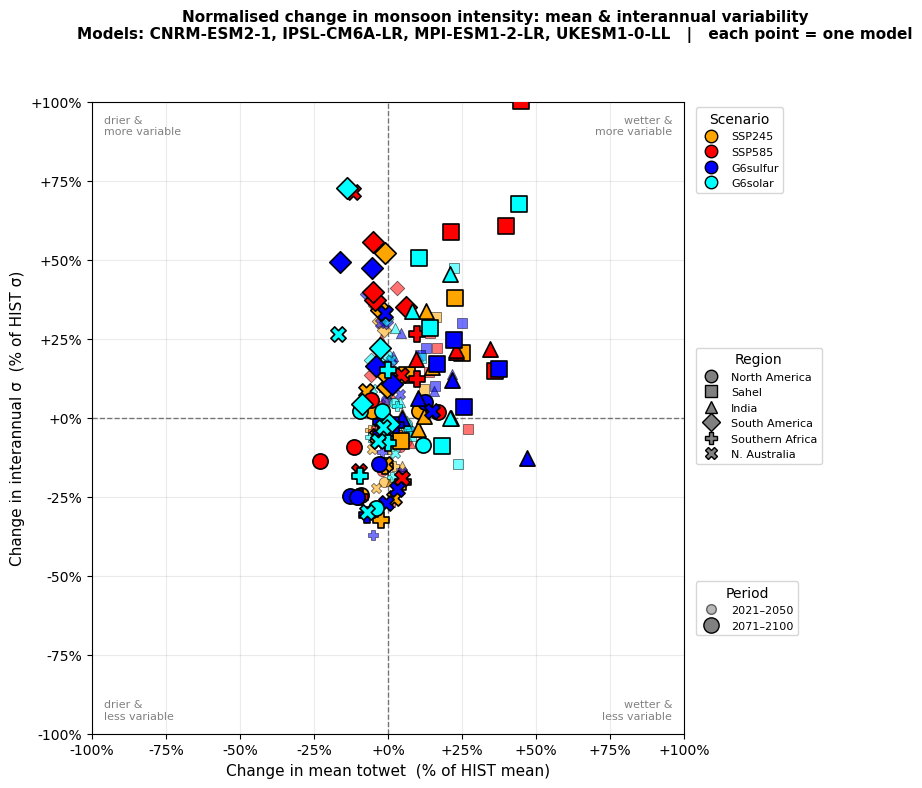

Saved → multimodel_totwet_normalised_scatter.png


In [14]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

base_dir = Path("~/UoE/20260218_Monsoons/rainyseason_output_files").expanduser()
missval  = -999.0

models = [
    "CNRM-ESM2-1",
    "IPSL-CM6A-LR",
    "MPI-ESM1-2-LR",
    "UKESM1-0-LL",
]

future_scens = ["SSP245", "SSP585", "G6sulfur", "G6solar"]
periods      = ["2021-2050", "2071-2100"]

scenario_styles = {
    "SSP245":   {"color": "orange", "marker": "o"},
    "SSP585":   {"color": "red",    "marker": "s"},
    "G6sulfur": {"color": "blue",   "marker": "^"},
    "G6solar":  {"color": "cyan",   "marker": "D"},
}

domains = {
    "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}


def load_totwet(nc_file, dom):
    ds   = xr.open_dataset(nc_file)
    lats = ds.lat.values
    lons = ds.lon.values
    ilat = np.where((lats >= dom["lat"][0]) & (lats <= dom["lat"][1]))[0]
    ilon = np.where((lons >= dom["lon"][0]) & (lons <= dom["lon"][1]))[0]
    arr  = ds["totwet"].values[:, ilat, :][:, :, ilon].astype(float)
    arr[arr == missval] = np.nan
    ds.close()
    return np.nanmean(arr, axis=(1, 2))   # (years,)


def get_model_stats(scenario, period, dom):
    """Per-model (mean, std) of spatially averaged totwet."""
    means, stds = [], []
    for model in models:
        nc_file = base_dir / f"rainy_season_{model}_{scenario}_{period}.nc"
        if not nc_file.exists():
            print(f"  SKIP {nc_file.name}")
            continue
        try:
            vals = load_totwet(nc_file, dom)
            vals = vals[~np.isnan(vals)]
            means.append(np.mean(vals))
            stds.append(np.std(vals, ddof=1))
        except Exception as e:
            print(f"  ERROR {nc_file.name}: {e}")
    return np.array(means), np.array(stds)


# ── Pre-compute HIST per-model stats ──────────────────────────────────────
hist_means_all = {}
hist_stds_all  = {}
for region, dom in domains.items():
    hm, hs = get_model_stats("HIST", "1985-2014", dom)
    hist_means_all[region] = hm
    hist_stds_all[region]  = hs

# Normalisation factor = multi-model mean of HIST mean for each region
norm_mean = {r: np.mean(hist_means_all[r]) for r in domains}
norm_std  = {r: np.mean(hist_stds_all[r])  for r in domains}


# ── Single figure: all regions on one set of axes ─────────────────────────
# Use region as the marker label via annotation; all share same x/y scale
region_markers = {
    "North America":   "o",
    "Sahel":           "s",
    "India":           "^",
    "South America":   "D",
    "Southern Africa": "P",
    "N. Australia":    "X",
}
region_colors_outline = {        # subtle outline per region so they're distinguishable
    "North America":   "#333333",
    "Sahel":           "#333333",
    "India":           "#333333",
    "South America":   "#333333",
    "Southern Africa": "#333333",
    "N. Australia":    "#333333",
}

fig, ax = plt.subplots(figsize=(10, 8))

for period in periods:
    ms        = 120 if period == "2071-2100" else 55
    edgewidth = 1.2 if period == "2071-2100" else 0.6
    alpha     = 1.0 if period == "2071-2100" else 0.55

    for scen in future_scens:
        col = scenario_styles[scen]["color"]

        for region, dom in domains.items():
            mkr    = region_markers[region]
            h_means = hist_means_all[region]
            h_stds  = hist_stds_all[region]
            nf_mean = norm_mean[region]
            nf_std  = norm_std[region]

            s_means, s_stds = get_model_stats(scen, period, dom)
            if len(s_means) == 0:
                continue

            n = min(len(s_means), len(h_means))

            # Normalised changes (fractional, so 0.1 = 10% change)
            delta_mean = (s_means[:n] - h_means[:n]) / nf_mean
            delta_std  = (s_stds[:n]  - h_stds[:n])  / nf_std

            ax.scatter(delta_mean, delta_std,
                       color=col, marker=mkr, s=ms,
                       edgecolors="black", linewidths=edgewidth,
                       alpha=alpha, zorder=3)

ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)

# ── Format axes as percentage ─────────────────────────────────────────────
from matplotlib.ticker import FuncFormatter
pct_fmt = FuncFormatter(lambda x, _: f"{x*100:+.0f}%")
ax.xaxis.set_major_formatter(pct_fmt)
ax.yaxis.set_major_formatter(pct_fmt)

ax.set_xlabel("Change in mean totwet  (% of HIST mean)", fontsize=11)
ax.set_ylabel("Change in interannual σ  (% of HIST σ)", fontsize=11)
ax.grid(True, alpha=0.25)

# Quadrant labels
# xlim = ax.get_xlim(); ylim = ax.get_ylim()
# pad  = 0.02
# ax.text(xlim[1]-pad*(xlim[1]-xlim[0]), ylim[1]-pad*(ylim[1]-ylim[0]),
#         "wetter &\nmore variable",  ha="right", va="top",   fontsize=8, color="grey")
# ax.text(xlim[0]+pad*(xlim[1]-xlim[0]), ylim[1]-pad*(ylim[1]-ylim[0]),
#         "drier &\nmore variable",   ha="left",  va="top",   fontsize=8, color="grey")
# ax.text(xlim[1]-pad*(xlim[1]-xlim[0]), ylim[0]+pad*(ylim[1]-ylim[0]),
#         "wetter &\nless variable",  ha="right", va="bottom",fontsize=8, color="grey")
# ax.text(xlim[0]+pad*(xlim[1]-xlim[0]), ylim[0]+pad*(ylim[1]-ylim[0]),
#         "drier &\nless variable",   ha="left",  va="bottom",fontsize=8, color="grey")

ax.set_xlim(-1.0, 1.0)
ax.set_ylim(-1.0, 1.0)

# Quadrant labels
pad = 0.02
ax.text( 0.98,  0.98, "wetter &\nmore variable",  ha="right", va="top",    fontsize=8, color="grey", transform=ax.transAxes)
ax.text( 0.02,  0.98, "drier &\nmore variable",   ha="left",  va="top",    fontsize=8, color="grey", transform=ax.transAxes)
ax.text( 0.98,  0.02, "wetter &\nless variable",  ha="right", va="bottom", fontsize=8, color="grey", transform=ax.transAxes)
ax.text( 0.02,  0.02, "drier &\nless variable",   ha="left",  va="bottom", fontsize=8, color="grey", transform=ax.transAxes)

# ── Two-part legend: scenarios (colour) + regions (marker) ───────────────
scen_handles = [
    plt.Line2D([0],[0], marker="o", color="w",
               markerfacecolor=scenario_styles[s]["color"],
               markeredgecolor="black", markersize=9, label=s)
    for s in future_scens
]
region_handles = [
    plt.Line2D([0],[0], marker=region_markers[r], color="w",
               markerfacecolor="grey", markeredgecolor="black",
               markersize=9, label=r)
    for r in domains
]
period_handles = [
    plt.Line2D([0],[0], marker="o", color="w",
               markerfacecolor="grey", markeredgecolor="black",
               markersize=s, alpha=a, label=f"{p}")
    for p, s, a in [("2021–2050", 7, 0.55), ("2071–2100", 11, 1.0)]
]

leg1 = ax.legend(handles=scen_handles,   title="Scenario", fontsize=8,
                 loc="upper left",        bbox_to_anchor=(1.01, 1.0))
leg2 = ax.legend(handles=region_handles, title="Region",   fontsize=8,
                 loc="upper left",        bbox_to_anchor=(1.01, 0.62))
leg3 = ax.legend(handles=period_handles, title="Period",   fontsize=8,
                 loc="upper left",        bbox_to_anchor=(1.01, 0.25))
ax.add_artist(leg1)
ax.add_artist(leg2)

plt.suptitle(
    "Normalised change in monsoon intensity: mean & interannual variability\n"
    f"Models: {', '.join(models)}   |   each point = one model",
    fontsize=11, fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 0.82, 0.95])

outpng = base_dir / "multimodel_totwet_normalised_scatter.png"
plt.savefig(outpng, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {outpng.name}")

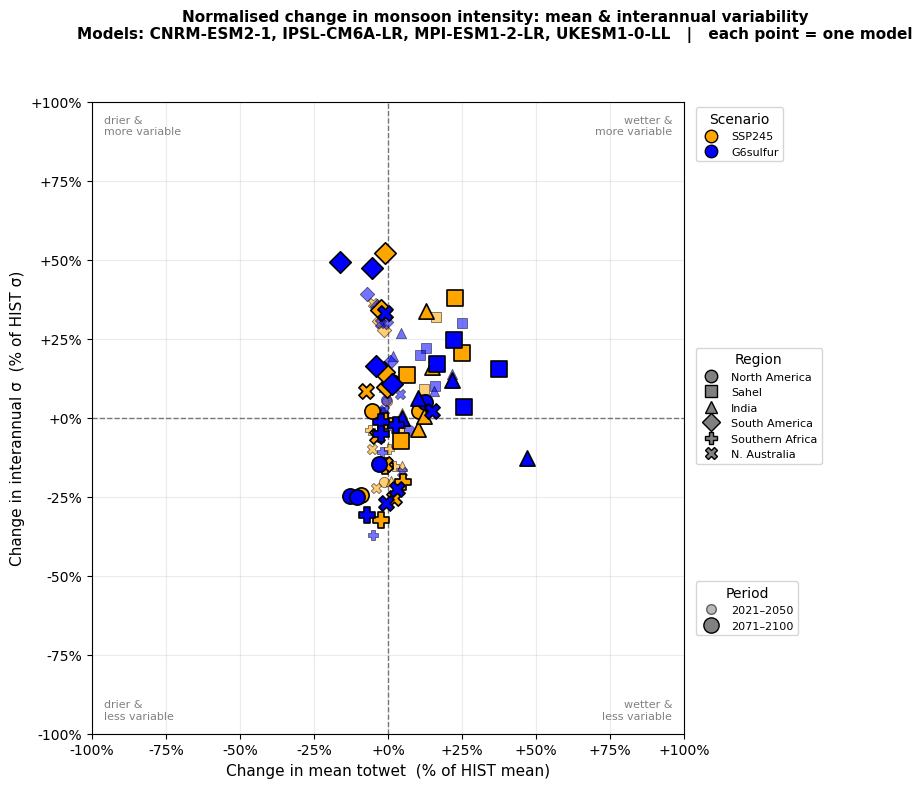

Saved → multimodel_totwet_normalised_scatter_SSP245_and_G6sulfur.png


In [16]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

base_dir = Path("~/UoE/20260218_Monsoons/rainyseason_output_files").expanduser()
missval  = -999.0

models = [
    "CNRM-ESM2-1",
    "IPSL-CM6A-LR",
    "MPI-ESM1-2-LR",
    "UKESM1-0-LL",
]

# future_scens = ["SSP245", "SSP585", "G6sulfur", "G6solar"]
future_scens = ["SSP245", "G6sulfur"]
periods      = ["2021-2050", "2071-2100"]

scenario_styles = {
    "SSP245":   {"color": "orange", "marker": "o"},
    # "SSP585":   {"color": "red",    "marker": "s"},
    "G6sulfur": {"color": "blue",   "marker": "^"},
    # "G6solar":  {"color": "cyan",   "marker": "D"},
}

domains = {
    "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}


def load_totwet(nc_file, dom):
    ds   = xr.open_dataset(nc_file)
    lats = ds.lat.values
    lons = ds.lon.values
    ilat = np.where((lats >= dom["lat"][0]) & (lats <= dom["lat"][1]))[0]
    ilon = np.where((lons >= dom["lon"][0]) & (lons <= dom["lon"][1]))[0]
    arr  = ds["totwet"].values[:, ilat, :][:, :, ilon].astype(float)
    arr[arr == missval] = np.nan
    ds.close()
    return np.nanmean(arr, axis=(1, 2))   # (years,)


def get_model_stats(scenario, period, dom):
    """Per-model (mean, std) of spatially averaged totwet."""
    means, stds = [], []
    for model in models:
        nc_file = base_dir / f"rainy_season_{model}_{scenario}_{period}.nc"
        if not nc_file.exists():
            print(f"  SKIP {nc_file.name}")
            continue
        try:
            vals = load_totwet(nc_file, dom)
            vals = vals[~np.isnan(vals)]
            means.append(np.mean(vals))
            stds.append(np.std(vals, ddof=1))
        except Exception as e:
            print(f"  ERROR {nc_file.name}: {e}")
    return np.array(means), np.array(stds)


# ── Pre-compute HIST per-model stats ──────────────────────────────────────
hist_means_all = {}
hist_stds_all  = {}
for region, dom in domains.items():
    hm, hs = get_model_stats("HIST", "1985-2014", dom)
    hist_means_all[region] = hm
    hist_stds_all[region]  = hs

# Normalisation factor = multi-model mean of HIST mean for each region
norm_mean = {r: np.mean(hist_means_all[r]) for r in domains}
norm_std  = {r: np.mean(hist_stds_all[r])  for r in domains}


# ── Single figure: all regions on one set of axes ─────────────────────────
# Use region as the marker label via annotation; all share same x/y scale
region_markers = {
    "North America":   "o",
    "Sahel":           "s",
    "India":           "^",
    "South America":   "D",
    "Southern Africa": "P",
    "N. Australia":    "X",
}
region_colors_outline = {        # subtle outline per region so they're distinguishable
    "North America":   "#333333",
    "Sahel":           "#333333",
    "India":           "#333333",
    "South America":   "#333333",
    "Southern Africa": "#333333",
    "N. Australia":    "#333333",
}

fig, ax = plt.subplots(figsize=(10, 8))

for period in periods:
    ms        = 120 if period == "2071-2100" else 55
    edgewidth = 1.2 if period == "2071-2100" else 0.6
    alpha     = 1.0 if period == "2071-2100" else 0.55

    for scen in future_scens:
        col = scenario_styles[scen]["color"]

        for region, dom in domains.items():
            mkr    = region_markers[region]
            h_means = hist_means_all[region]
            h_stds  = hist_stds_all[region]
            nf_mean = norm_mean[region]
            nf_std  = norm_std[region]

            s_means, s_stds = get_model_stats(scen, period, dom)
            if len(s_means) == 0:
                continue

            n = min(len(s_means), len(h_means))

            # Normalised changes (fractional, so 0.1 = 10% change)
            delta_mean = (s_means[:n] - h_means[:n]) / nf_mean
            delta_std  = (s_stds[:n]  - h_stds[:n])  / nf_std

            ax.scatter(delta_mean, delta_std,
                       color=col, marker=mkr, s=ms,
                       edgecolors="black", linewidths=edgewidth,
                       alpha=alpha, zorder=3)

ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)

# ── Format axes as percentage ─────────────────────────────────────────────
from matplotlib.ticker import FuncFormatter
pct_fmt = FuncFormatter(lambda x, _: f"{x*100:+.0f}%")
ax.xaxis.set_major_formatter(pct_fmt)
ax.yaxis.set_major_formatter(pct_fmt)

ax.set_xlabel("Change in mean totwet  (% of HIST mean)", fontsize=11)
ax.set_ylabel("Change in interannual σ  (% of HIST σ)", fontsize=11)
ax.grid(True, alpha=0.25)

# Quadrant labels
# xlim = ax.get_xlim(); ylim = ax.get_ylim()
# pad  = 0.02
# ax.text(xlim[1]-pad*(xlim[1]-xlim[0]), ylim[1]-pad*(ylim[1]-ylim[0]),
#         "wetter &\nmore variable",  ha="right", va="top",   fontsize=8, color="grey")
# ax.text(xlim[0]+pad*(xlim[1]-xlim[0]), ylim[1]-pad*(ylim[1]-ylim[0]),
#         "drier &\nmore variable",   ha="left",  va="top",   fontsize=8, color="grey")
# ax.text(xlim[1]-pad*(xlim[1]-xlim[0]), ylim[0]+pad*(ylim[1]-ylim[0]),
#         "wetter &\nless variable",  ha="right", va="bottom",fontsize=8, color="grey")
# ax.text(xlim[0]+pad*(xlim[1]-xlim[0]), ylim[0]+pad*(ylim[1]-ylim[0]),
#         "drier &\nless variable",   ha="left",  va="bottom",fontsize=8, color="grey")

ax.set_xlim(-1.0, 1.0)
ax.set_ylim(-1.0, 1.0)

# Quadrant labels
pad = 0.02
ax.text( 0.98,  0.98, "wetter &\nmore variable",  ha="right", va="top",    fontsize=8, color="grey", transform=ax.transAxes)
ax.text( 0.02,  0.98, "drier &\nmore variable",   ha="left",  va="top",    fontsize=8, color="grey", transform=ax.transAxes)
ax.text( 0.98,  0.02, "wetter &\nless variable",  ha="right", va="bottom", fontsize=8, color="grey", transform=ax.transAxes)
ax.text( 0.02,  0.02, "drier &\nless variable",   ha="left",  va="bottom", fontsize=8, color="grey", transform=ax.transAxes)

# ── Two-part legend: scenarios (colour) + regions (marker) ───────────────
scen_handles = [
    plt.Line2D([0],[0], marker="o", color="w",
               markerfacecolor=scenario_styles[s]["color"],
               markeredgecolor="black", markersize=9, label=s)
    for s in future_scens
]
region_handles = [
    plt.Line2D([0],[0], marker=region_markers[r], color="w",
               markerfacecolor="grey", markeredgecolor="black",
               markersize=9, label=r)
    for r in domains
]
period_handles = [
    plt.Line2D([0],[0], marker="o", color="w",
               markerfacecolor="grey", markeredgecolor="black",
               markersize=s, alpha=a, label=f"{p}")
    for p, s, a in [("2021–2050", 7, 0.55), ("2071–2100", 11, 1.0)]
]

leg1 = ax.legend(handles=scen_handles,   title="Scenario", fontsize=8,
                 loc="upper left",        bbox_to_anchor=(1.01, 1.0))
leg2 = ax.legend(handles=region_handles, title="Region",   fontsize=8,
                 loc="upper left",        bbox_to_anchor=(1.01, 0.62))
leg3 = ax.legend(handles=period_handles, title="Period",   fontsize=8,
                 loc="upper left",        bbox_to_anchor=(1.01, 0.25))
ax.add_artist(leg1)
ax.add_artist(leg2)

plt.suptitle(
    "Normalised change in monsoon intensity: mean & interannual variability\n"
    f"Models: {', '.join(models)}   |   each point = one model",
    fontsize=11, fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 0.82, 0.95])

outpng = base_dir / "multimodel_totwet_normalised_scatter_SSP245_and_G6sulfur.png"
plt.savefig(outpng, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {outpng.name}")

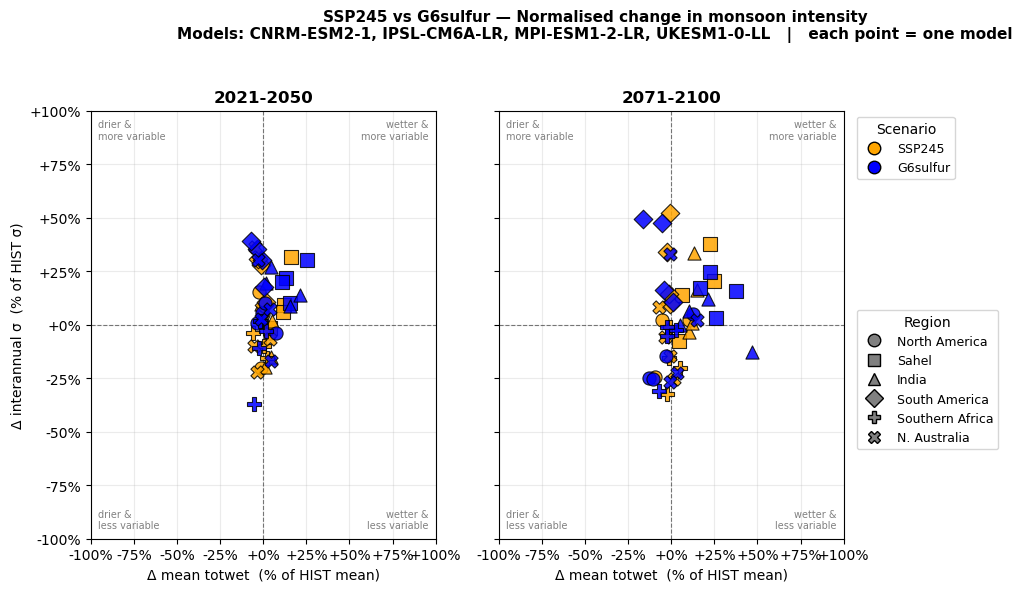

Saved → SSP245_vs_G6sulfur_normalised_scatter.png


In [17]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings("ignore")

base_dir = Path("~/UoE/20260218_Monsoons/rainyseason_output_files").expanduser()
missval  = -999.0

models = [
    "CNRM-ESM2-1",
    "IPSL-CM6A-LR",
    "MPI-ESM1-2-LR",
    "UKESM1-0-LL",
]

future_scens = ["SSP245", "G6sulfur"]
periods      = ["2021-2050", "2071-2100"]

scenario_styles = {
    "SSP245":   {"color": "orange", "marker": "o"},
    "G6sulfur": {"color": "blue",   "marker": "^"},
}

region_markers = {
    "North America":   "o",
    "Sahel":           "s",
    "India":           "^",
    "South America":   "D",
    "Southern Africa": "P",
    "N. Australia":    "X",
}

domains = {
    "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}


def load_totwet(nc_file, dom):
    ds   = xr.open_dataset(nc_file)
    lats = ds.lat.values
    lons = ds.lon.values
    ilat = np.where((lats >= dom["lat"][0]) & (lats <= dom["lat"][1]))[0]
    ilon = np.where((lons >= dom["lon"][0]) & (lons <= dom["lon"][1]))[0]
    arr  = ds["totwet"].values[:, ilat, :][:, :, ilon].astype(float)
    arr[arr == missval] = np.nan
    ds.close()
    return np.nanmean(arr, axis=(1, 2))


def get_model_stats(scenario, period, dom):
    means, stds = [], []
    for model in models:
        nc_file = base_dir / f"rainy_season_{model}_{scenario}_{period}.nc"
        if not nc_file.exists():
            print(f"  SKIP {nc_file.name}")
            continue
        try:
            vals = load_totwet(nc_file, dom)
            vals = vals[~np.isnan(vals)]
            means.append(np.mean(vals))
            stds.append(np.std(vals, ddof=1))
        except Exception as e:
            print(f"  ERROR {nc_file.name}: {e}")
    return np.array(means), np.array(stds)


# ── Pre-compute HIST stats & normalisation ────────────────────────────────
hist_means_all = {}
hist_stds_all  = {}
for region, dom in domains.items():
    hm, hs = get_model_stats("HIST", "1985-2014", dom)
    hist_means_all[region] = hm
    hist_stds_all[region]  = hs

norm_mean = {r: np.mean(hist_means_all[r]) for r in domains}
norm_std  = {r: np.mean(hist_stds_all[r])  for r in domains}

pct_fmt = FuncFormatter(lambda x, _: f"{x*100:+.0f}%")

# ── 1 row × 2 cols: left=2021-2050, right=2071-2100 ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

for ax, period in zip(axes, periods):

    for scen in future_scens:
        col = scenario_styles[scen]["color"]

        for region, dom in domains.items():
            mkr     = region_markers[region]
            h_means = hist_means_all[region]
            h_stds  = hist_stds_all[region]
            nf_mean = norm_mean[region]
            nf_std  = norm_std[region]

            s_means, s_stds = get_model_stats(scen, period, dom)
            if len(s_means) == 0:
                continue

            n = min(len(s_means), len(h_means))
            delta_mean = (s_means[:n] - h_means[:n]) / nf_mean
            delta_std  = (s_stds[:n]  - h_stds[:n])  / nf_std

            ax.scatter(delta_mean, delta_std,
                       color=col, marker=mkr, s=90,
                       edgecolors="black", linewidths=0.8,
                       alpha=0.85, zorder=3)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.xaxis.set_major_formatter(pct_fmt)
    ax.yaxis.set_major_formatter(pct_fmt)
    ax.set_title(period, fontsize=12, fontweight="bold")
    ax.set_xlabel("Δ mean totwet  (% of HIST mean)", fontsize=10)
    ax.grid(True, alpha=0.25)

    # Quadrant labels
    for x, y, txt, ha, va in [
        (0.98, 0.98, "wetter &\nmore variable",  "right", "top"),
        (0.02, 0.98, "drier &\nmore variable",   "left",  "top"),
        (0.98, 0.02, "wetter &\nless variable",  "right", "bottom"),
        (0.02, 0.02, "drier &\nless variable",   "left",  "bottom"),
    ]:
        ax.text(x, y, txt, ha=ha, va=va, fontsize=7, color="grey",
                transform=ax.transAxes)

axes[0].set_ylabel("Δ interannual σ  (% of HIST σ)", fontsize=10)

# ── Legend ────────────────────────────────────────────────────────────────
scen_handles = [
    plt.Line2D([0],[0], marker="o", color="w",
               markerfacecolor=scenario_styles[s]["color"],
               markeredgecolor="black", markersize=9, label=s)
    for s in future_scens
]
region_handles = [
    plt.Line2D([0],[0], marker=region_markers[r], color="w",
               markerfacecolor="grey", markeredgecolor="black",
               markersize=9, label=r)
    for r in domains
]

leg1 = axes[1].legend(handles=scen_handles,   title="Scenario", fontsize=9,
                      loc="upper left", bbox_to_anchor=(1.02, 1.0))
leg2 = axes[1].legend(handles=region_handles, title="Region",   fontsize=9,
                      loc="upper left", bbox_to_anchor=(1.02, 0.55))
axes[1].add_artist(leg1)

plt.suptitle(
    "SSP245 vs G6sulfur — Normalised change in monsoon intensity\n"
    f"Models: {', '.join(models)}   |   each point = one model",
    fontsize=11, fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 0.85, 0.95])

outpng = base_dir / "SSP245_vs_G6sulfur_normalised_scatter.png"
plt.savefig(outpng, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {outpng.name}")

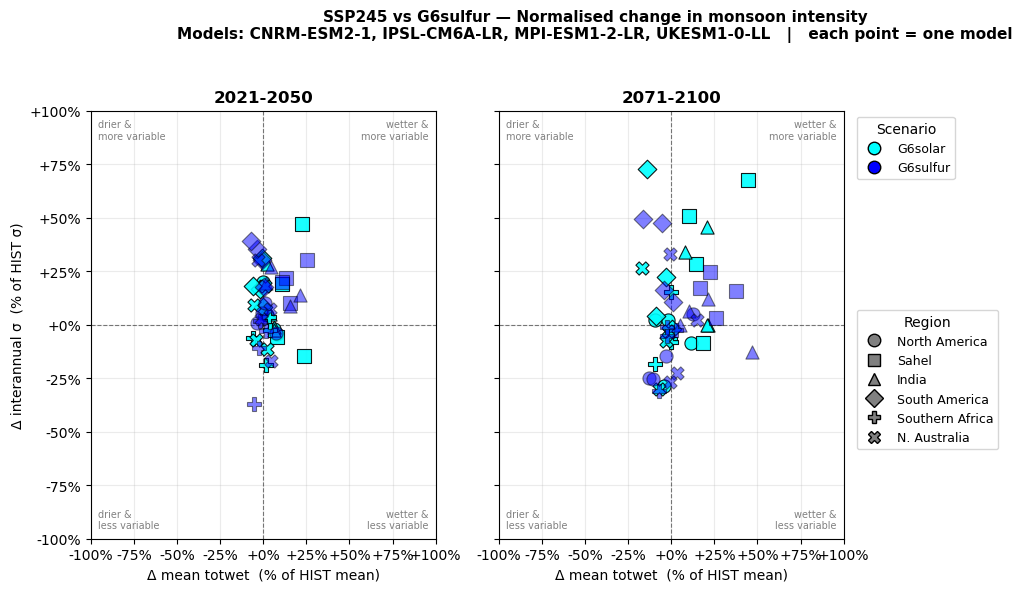

Saved → G6solar_vs_G6sulfur_normalised_scatter.png


In [21]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings("ignore")

base_dir = Path("~/UoE/20260218_Monsoons/rainyseason_output_files").expanduser()
missval  = -999.0

models = [
    "CNRM-ESM2-1",
    "IPSL-CM6A-LR",
    "MPI-ESM1-2-LR",
    "UKESM1-0-LL",
]

future_scens = ["G6solar", "G6sulfur"]
periods      = ["2021-2050", "2071-2100"]

scenario_styles = {
    "G6solar":  {"color": "cyan",   "marker": "D", "trans": 0.9},
    "G6sulfur": {"color": "blue",   "marker": "^","trans": 0.5 }
}

region_markers = {
    "North America":   "o",
    "Sahel":           "s",
    "India":           "^",
    "South America":   "D",
    "Southern Africa": "P",
    "N. Australia":    "X",
}

domains = {
    "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}


def load_totwet(nc_file, dom):
    ds   = xr.open_dataset(nc_file)
    lats = ds.lat.values
    lons = ds.lon.values
    ilat = np.where((lats >= dom["lat"][0]) & (lats <= dom["lat"][1]))[0]
    ilon = np.where((lons >= dom["lon"][0]) & (lons <= dom["lon"][1]))[0]
    arr  = ds["totwet"].values[:, ilat, :][:, :, ilon].astype(float)
    arr[arr == missval] = np.nan
    ds.close()
    return np.nanmean(arr, axis=(1, 2))


def get_model_stats(scenario, period, dom):
    means, stds = [], []
    for model in models:
        nc_file = base_dir / f"rainy_season_{model}_{scenario}_{period}.nc"
        if not nc_file.exists():
            print(f"  SKIP {nc_file.name}")
            continue
        try:
            vals = load_totwet(nc_file, dom)
            vals = vals[~np.isnan(vals)]
            means.append(np.mean(vals))
            stds.append(np.std(vals, ddof=1))
        except Exception as e:
            print(f"  ERROR {nc_file.name}: {e}")
    return np.array(means), np.array(stds)


# ── Pre-compute HIST stats & normalisation ────────────────────────────────
hist_means_all = {}
hist_stds_all  = {}
for region, dom in domains.items():
    hm, hs = get_model_stats("HIST", "1985-2014", dom)
    hist_means_all[region] = hm
    hist_stds_all[region]  = hs

norm_mean = {r: np.mean(hist_means_all[r]) for r in domains}
norm_std  = {r: np.mean(hist_stds_all[r])  for r in domains}

pct_fmt = FuncFormatter(lambda x, _: f"{x*100:+.0f}%")

# ── 1 row × 2 cols: left=2021-2050, right=2071-2100 ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

for ax, period in zip(axes, periods):

    for scen in future_scens:
        col = scenario_styles[scen]["color"]
        alf = scenario_styles[scen]["trans"]

        for region, dom in domains.items():
            mkr     = region_markers[region]
            h_means = hist_means_all[region]
            h_stds  = hist_stds_all[region]
            nf_mean = norm_mean[region]
            nf_std  = norm_std[region]

            s_means, s_stds = get_model_stats(scen, period, dom)
            if len(s_means) == 0:
                continue

            n = min(len(s_means), len(h_means))
            delta_mean = (s_means[:n] - h_means[:n]) / nf_mean
            delta_std  = (s_stds[:n]  - h_stds[:n])  / nf_std

            ax.scatter(delta_mean, delta_std,
                       color=col, marker=mkr, s=90,
                       edgecolors="black", linewidths=0.8,
                       alpha=alf, zorder=3)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.xaxis.set_major_formatter(pct_fmt)
    ax.yaxis.set_major_formatter(pct_fmt)
    ax.set_title(period, fontsize=12, fontweight="bold")
    ax.set_xlabel("Δ mean totwet  (% of HIST mean)", fontsize=10)
    ax.grid(True, alpha=0.25)

    # Quadrant labels
    for x, y, txt, ha, va in [
        (0.98, 0.98, "wetter &\nmore variable",  "right", "top"),
        (0.02, 0.98, "drier &\nmore variable",   "left",  "top"),
        (0.98, 0.02, "wetter &\nless variable",  "right", "bottom"),
        (0.02, 0.02, "drier &\nless variable",   "left",  "bottom"),
    ]:
        ax.text(x, y, txt, ha=ha, va=va, fontsize=7, color="grey",
                transform=ax.transAxes)

axes[0].set_ylabel("Δ interannual σ  (% of HIST σ)", fontsize=10)

# ── Legend ────────────────────────────────────────────────────────────────
scen_handles = [
    plt.Line2D([0],[0], marker="o", color="w",
               markerfacecolor=scenario_styles[s]["color"],
               markeredgecolor="black", markersize=9, label=s)
    for s in future_scens
]
region_handles = [
    plt.Line2D([0],[0], marker=region_markers[r], color="w",
               markerfacecolor="grey", markeredgecolor="black",
               markersize=9, label=r)
    for r in domains
]

leg1 = axes[1].legend(handles=scen_handles,   title="Scenario", fontsize=9,
                      loc="upper left", bbox_to_anchor=(1.02, 1.0))
leg2 = axes[1].legend(handles=region_handles, title="Region",   fontsize=9,
                      loc="upper left", bbox_to_anchor=(1.02, 0.55))
axes[1].add_artist(leg1)

plt.suptitle(
    "SSP245 vs G6sulfur — Normalised change in monsoon intensity\n"
    f"Models: {', '.join(models)}   |   each point = one model",
    fontsize=11, fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 0.85, 0.95])

outpng = base_dir / "G6solar_vs_G6sulfur_normalised_scatter.png"
plt.savefig(outpng, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {outpng.name}")

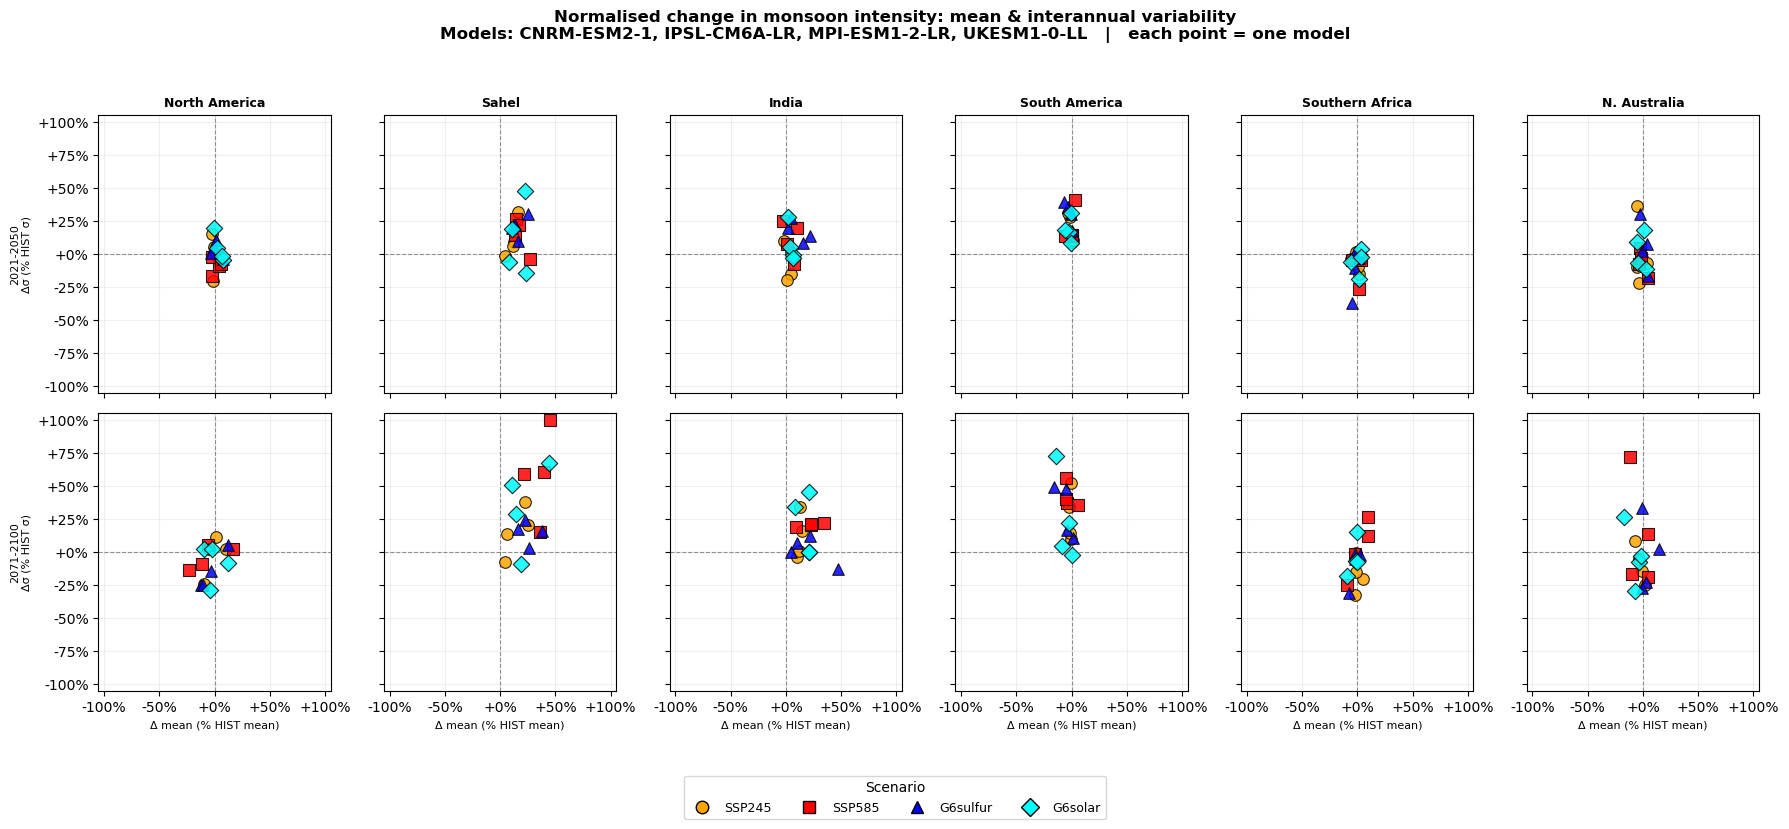

Saved → multimodel_totwet_normalised_scatter_multipanel.png


In [13]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

base_dir = Path("~/UoE/20260218_Monsoons/rainyseason_output_files").expanduser()
missval  = -999.0

models = [
    "CNRM-ESM2-1",
    "IPSL-CM6A-LR",
    "MPI-ESM1-2-LR",
    "UKESM1-0-LL",
]

future_scens = ["SSP245", "SSP585", "G6sulfur", "G6solar"]
periods      = ["2021-2050", "2071-2100"]

scenario_styles = {
    "SSP245":   {"color": "orange", "marker": "o"},
    "SSP585":   {"color": "red",    "marker": "s"},
    "G6sulfur": {"color": "blue",   "marker": "^"},
    "G6solar":  {"color": "cyan",   "marker": "D"},
}

domains = {
    "North America":   {"lat": (18.0,  33.0),  "lon": (248.0, 258.0)},
    "Sahel":           {"lat": (7.0,   18.5),  "lon": (0.0,   40.0)},
    "India":           {"lat": (15.0,  27.0),  "lon": (73.0,  87.0)},
    "South America":   {"lat": (-18.5, -7.0),  "lon": (300.0, 318.0)},
    "Southern Africa": {"lat": (-18.5, -7.0),  "lon": (19.5,  31.0)},
    "N. Australia":    {"lat": (-21.0, -9.5),  "lon": (120.5, 149.0)},
}


def load_totwet(nc_file, dom):
    ds   = xr.open_dataset(nc_file)
    lats = ds.lat.values
    lons = ds.lon.values
    ilat = np.where((lats >= dom["lat"][0]) & (lats <= dom["lat"][1]))[0]
    ilon = np.where((lons >= dom["lon"][0]) & (lons <= dom["lon"][1]))[0]
    arr  = ds["totwet"].values[:, ilat, :][:, :, ilon].astype(float)
    arr[arr == missval] = np.nan
    ds.close()
    return np.nanmean(arr, axis=(1, 2))


def get_model_stats(scenario, period, dom):
    means, stds = [], []
    for model in models:
        nc_file = base_dir / f"rainy_season_{model}_{scenario}_{period}.nc"
        if not nc_file.exists():
            print(f"  SKIP {nc_file.name}")
            continue
        try:
            vals = load_totwet(nc_file, dom)
            vals = vals[~np.isnan(vals)]
            means.append(np.mean(vals))
            stds.append(np.std(vals, ddof=1))
        except Exception as e:
            print(f"  ERROR {nc_file.name}: {e}")
    return np.array(means), np.array(stds)


# ── Pre-compute HIST per-model stats & normalisation factors ──────────────
hist_means_all = {}
hist_stds_all  = {}
for region, dom in domains.items():
    hm, hs = get_model_stats("HIST", "1985-2014", dom)
    hist_means_all[region] = hm
    hist_stds_all[region]  = hs

norm_mean = {r: np.mean(hist_means_all[r]) for r in domains}
norm_std  = {r: np.mean(hist_stds_all[r])  for r in domains}


# ── Figure: 2 rows × 6 cols ───────────────────────────────────────────────
from matplotlib.ticker import FuncFormatter
pct_fmt = FuncFormatter(lambda x, _: f"{x*100:+.0f}%")

region_list = list(domains.keys())
fig, axes = plt.subplots(2, 6, figsize=(18, 8), sharex=True, sharey=True)

# Collect global min/max for consistent axis limits after plotting
all_dx, all_dy = [], []

for row, period in enumerate(periods):
    for col, region in enumerate(region_list):
        ax  = axes[row, col]
        dom = domains[region]

        h_means = hist_means_all[region]
        h_stds  = hist_stds_all[region]
        nf_mean = norm_mean[region]
        nf_std  = norm_std[region]

        for scen in future_scens:
            s_means, s_stds = get_model_stats(scen, period, dom)
            if len(s_means) == 0:
                continue

            n = min(len(s_means), len(h_means))
            delta_mean = (s_means[:n] - h_means[:n]) / nf_mean
            delta_std  = (s_stds[:n]  - h_stds[:n])  / nf_std

            all_dx.extend(delta_mean.tolist())
            all_dy.extend(delta_std.tolist())

            col_c = scenario_styles[scen]["color"]
            mkr   = scenario_styles[scen]["marker"]

            ax.scatter(delta_mean, delta_std,
                       color=col_c, marker=mkr, s=70,
                       edgecolors="black", linewidths=0.8,
                       alpha=0.85, zorder=3)

        ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
        ax.xaxis.set_major_formatter(pct_fmt)
        ax.yaxis.set_major_formatter(pct_fmt)
        ax.grid(True, alpha=0.2)

        # Column titles (region) on top row only
        if row == 0:
            ax.set_title(region, fontsize=9, fontweight="bold")

        # Row labels on leftmost column only
        if col == 0:
            ax.set_ylabel(f"{period}\nΔσ (% HIST σ)", fontsize=8)

        # x-axis label on bottom row only
        if row == 1:
            ax.set_xlabel("Δ mean (% HIST mean)", fontsize=8)

# ── Uniform axis limits with a little padding ─────────────────────────────
pad  = 0.05
xabs = max(abs(np.nanmin(all_dx)), abs(np.nanmax(all_dx)))
yabs = max(abs(np.nanmin(all_dy)), abs(np.nanmax(all_dy)))
lim  = max(xabs, yabs) * (1 + pad)
for ax in axes.flat:
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

# ── Shared legend ─────────────────────────────────────────────────────────
scen_handles = [
    plt.Line2D([0],[0], marker=scenario_styles[s]["marker"], color="w",
               markerfacecolor=scenario_styles[s]["color"],
               markeredgecolor="black", markersize=9, label=s)
    for s in future_scens
]
fig.legend(handles=scen_handles, title="Scenario", fontsize=9,
           loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.04))

plt.suptitle(
    "Normalised change in monsoon intensity: mean & interannual variability\n"
    f"Models: {', '.join(models)}   |   each point = one model",
    fontsize=12, fontweight="bold"
)
plt.tight_layout(rect=[0, 0.06, 1, 0.95])

outpng = base_dir / "multimodel_totwet_normalised_scatter_multipanel.png"
plt.savefig(outpng, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {outpng.name}")